In [56]:
from pathlib import Path
# DATA_DIR: workspace root where all 5 CSV files live. Change here if relocated.
DATA_DIR = Path(r"c:\Users\lanka\Downloads\archive")

# Decoding Sunrisers Hyderabad's IPL 2026 Campaign
## A Ball-by-Ball Performance Analysis

**Author:** Lanka Saimanikanta Sharma  
**Programme:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026  
**Season:** IPL 2026 (March 28 – May 9, 2026)

---

### Datasets Used

| File | Rows | Description |
|---|---|---|
| `deliveries (1).csv` | 17,477 | Ball-by-ball delivery records — primary dataset |
| `batting_stats.csv` | 15 | Top-15 IPL 2026 batting aggregates |
| `bowling.csv` | 15 | Top-15 IPL 2026 bowling aggregates |
| `fielding_stats.csv` | 15 | Top-15 IPL 2026 catch leaders |
| `venues.csv` | 12 | IPL 2026 stadium metadata |

> **Note:** All analyses are based strictly on observed data for IPL 2026.  
> No win/loss modelling, outcome predictions, or multi-season claims are made.

---
## Section 1: Data Loading

Load all five CSV files from `DATA_DIR`. Verify row counts and schemas.

In [102]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
VISUALS = Path('visuals')
VISUALS.mkdir(exist_ok=True)

df_del    = pd.read_csv(DATA_DIR / 'deliveries (1).csv')
df_bat    = pd.read_csv(DATA_DIR / 'batting_stats.csv')
df_bowl   = pd.read_csv(DATA_DIR / 'bowling.csv')
df_field  = pd.read_csv(DATA_DIR / 'fielding_stats.csv')
df_venues = pd.read_csv(DATA_DIR / 'venues.csv')

print('All five CSV files loaded.')

All five CSV files loaded.


In [103]:
EXPECTED = {'df_del': 17477, 'df_bat': 15, 'df_bowl': 15, 'df_field': 15, 'df_venues': 12}
frames   = {'df_del': df_del, 'df_bat': df_bat, 'df_bowl': df_bowl,
            'df_field': df_field, 'df_venues': df_venues}

for name, df in frames.items():
    exp    = EXPECTED[name]
    status = 'PASS' if len(df) == exp else f'FAIL (expected {exp}, got {len(df)})'
    print(f'{name}: {len(df)} rows x {df.shape[1]} cols | {status}')
    print(f'  columns: {df.columns.tolist()}')
    print(f'  dtypes: {dict(df.dtypes)}')
    display(df.head(3))

errors = [n for n, d in frames.items() if len(d) != EXPECTED[n]]
if errors:
    raise AssertionError(f'Row count mismatch for: {errors}')
print('\nAll row-count assertions PASSED.')

df_del: 17477 rows x 19 cols | PASS
  columns: ['match_no', 'date', 'stage', 'venue', 'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs', 'wicket_type', 'player_dismissed', 'fielder']
  dtypes: {'match_no': dtype('int64'), 'date': <StringDtype(storage='python', na_value=nan)>, 'stage': <StringDtype(storage='python', na_value=nan)>, 'venue': <StringDtype(storage='python', na_value=nan)>, 'batting_team': <StringDtype(storage='python', na_value=nan)>, 'bowling_team': <StringDtype(storage='python', na_value=nan)>, 'innings': dtype('int64'), 'over': dtype('float64'), 'striker': <StringDtype(storage='python', na_value=nan)>, 'bowler': <StringDtype(storage='python', na_value=nan)>, 'runs_of_bat': dtype('int64'), 'extras': dtype('int64'), 'wide': dtype('int64'), 'legbyes': dtype('int64'), 'byes': dtype('int64'), 'noballs': dtype('int64'), 'wicket_type': <StringDtype(storage='python', na_value=nan)>, 'player_dism

,match_no,date,stage,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN


df_bat: 15 rows x 17 cols | PASS
  columns: ['position', 'batsman', 'team', 'matches', 'innings', 'runs', 'impact', 'average', 'strike_rate', 'not_outs', 'high_score', 'balls_faced', 'hundreds', 'fifties', 'ducks', 'fours', 'sixes']
  dtypes: {'position': dtype('int64'), 'batsman': <StringDtype(storage='python', na_value=nan)>, 'team': <StringDtype(storage='python', na_value=nan)>, 'matches': dtype('int64'), 'innings': dtype('int64'), 'runs': dtype('int64'), 'impact': dtype('float64'), 'average': dtype('float64'), 'strike_rate': dtype('float64'), 'not_outs': dtype('int64'), 'high_score': dtype('int64'), 'balls_faced': dtype('int64'), 'hundreds': dtype('int64'), 'fifties': dtype('int64'), 'ducks': dtype('int64'), 'fours': dtype('int64'), 'sixes': dtype('int64')}


,position,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
0,1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
1,2,KL Rahul,DC,8,8,358,317.6,51.14,185.49,1,152,193,1,2,1,36,19
2,3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32


df_bowl: 15 rows x 10 cols | PASS
  columns: ['Rank', 'Player', 'Team', 'Matches', 'Overs', 'Runs', 'Wickets', 'Average', 'Economy', 'Best Figures']
  dtypes: {'Rank': dtype('int64'), 'Player': <StringDtype(storage='python', na_value=nan)>, 'Team': <StringDtype(storage='python', na_value=nan)>, 'Matches': dtype('int64'), 'Overs': dtype('float64'), 'Runs': dtype('int64'), 'Wickets': dtype('int64'), 'Average': dtype('float64'), 'Economy': dtype('float64'), 'Best Figures': <StringDtype(storage='python', na_value=nan)>}


...

df_field: 15 rows x 6 cols | PASS
  columns: ['rank', 'player', 'team', 'matches', 'catches', 'cpm']
  dtypes: {'rank': dtype('int64'), 'player': <StringDtype(storage='python', na_value=nan)>, 'team': <StringDtype(storage='python', na_value=nan)>, 'matches': dtype('int64'), 'catches': dtype('int64'), 'cpm': dtype('float64')}


,rank,player,team,matches,catches,cpm
0,1,Rinku Singh,KKR,8,9,1.285
1,2,Devdutt Padikkal,RCB,8,9,1.125
2,3,Dewald Brevis,CSK,5,8,1.600


df_venues: 12 rows x 5 cols | PASS
  columns: ['venue_stadium', 'city', 'state', 'capacity', 'home_team']
  dtypes: {'venue_stadium': <StringDtype(storage='python', na_value=nan)>, 'city': <StringDtype(storage='python', na_value=nan)>, 'state': <StringDtype(storage='python', na_value=nan)>, 'capacity': dtype('int64'), 'home_team': <StringDtype(storage='python', na_value=nan)>}


,venue_stadium,city,state,capacity,home_team
0,Narendra Modi Stadium,Ahmedabad,Gujrat,132000,GT
1,Wankhede Stadium,Mumbai,Maharashtra,33108,MI
2,Eden Gardens,Kolkata,West Bengal,68000,KKR



All row-count assertions PASSED.


---
## Section 2: Data Cleaning and Normalisation

- Validate `over` encoding before creating any derived columns
- Add `over_number`, `ball_label`, `is_legal_delivery`, `phase`, `venue_clean`, `month`
- Normalise bowling.csv team names via TEAM_MAP
- Normalise `hitwicket` → `hit wicket`; replace empty dismissal strings with NaN
- Document and exclude `Best Figures` column entirely

### 2.0 Data Quality Note: Best Figures column

> The `Best Figures` column in `bowling.csv` contains values such as `Apr-32` which are a
> date-parse artefact: the source tool interpreted values like `4/32` as dates. The original
> values cannot be independently verified for all 15 rows. This column is loaded as a string
> and is **completely excluded from all calculations, tables, and visualisations** in this project.

In [104]:
# 3a. over field validation -- must run before any derived column
print('Step 1: First 30 unique over values (sorted)')
print(sorted(df_del['over'].unique())[:30])

ball_digits = df_del['over'].apply(lambda x: int(round((x % 1) * 10)))
assert ball_digits.between(1, 6).all(), \
    f'Unexpected ball digit(s): {ball_digits[~ball_digits.between(1,6)].unique()}'
print(f'Ball digits observed: {sorted(ball_digits.unique())}  -- PASSED [1,6]')

# Demonstrate extras-repeat encoding
_ex = (df_del.groupby(['match_no','innings','over'])
       .filter(lambda g: (g['wide']>0).any() and len(g)>1)
       .head(6))[['match_no','innings','over','striker','wide','noballs','wicket_type']]
print('\nExtras-repeat demo (wide rows share the same over label):')
display(_ex)
print('over encoding validated: ball labels 1-6; extras share the label of the interrupted delivery.')

Step 1: First 30 unique over values (sorted)
[np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6)]
Ball digits observed: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  -- PASSED [1,6]

Extras-repeat demo (wide rows share the same over label):


,match_no,innings,over,striker,wide,noballs,wicket_type
9,1,1,1.4,Abhishek Sharma,0,0,NaN
10,1,1,1.4,Abhishek Sharma,1,0,NaN
11,1,1,1.5,Abhishek Sharma,0,0,NaN
12,1,1,1.5,Abhishek Sharma,1,0,NaN
14,1,1,2.1,Abhishek Sharma,0,0,caught
15,1,1,2.1,Abhishek Sharma,1,0,bowled


over encoding validated: ball labels 1-6; extras share the label of the interrupted delivery.


In [105]:
# 3b. Derived columns
df_del['over_number']       = df_del['over'].astype(int)
df_del['ball_label']        = df_del['over'].apply(lambda x: int(round((x % 1) * 10)))
df_del['is_legal_delivery'] = (df_del['wide'] == 0) & (df_del['noballs'] == 0)

assert df_del['over_number'].between(0, 19).all()
assert df_del['ball_label'].between(1, 6).all()

print(f'over_number range : {df_del["over_number"].min()} - {df_del["over_number"].max()}  PASSED')
print(f'ball_label values : {sorted(df_del["ball_label"].unique())}  PASSED')
print(f'Legal deliveries  : {df_del["is_legal_delivery"].sum():,}')
print(f'Non-legal (extras): {(~df_del["is_legal_delivery"]).sum():,}')

over_number range : 0 - 19  PASSED
ball_label values : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  PASSED
Legal deliveries  : 16,669
Non-legal (extras): 808


In [106]:
# 3c. Phase column
conditions = [df_del['over_number'] <= 5, df_del['over_number'] >= 16]
choices    = ['Powerplay', 'Death']
df_del['phase'] = np.select(conditions, choices, default='Middle')

assert set(df_del['phase'].unique()) == {'Powerplay', 'Middle', 'Death'}
print('Phase column added.')
print(df_del['phase'].value_counts().to_string())

Phase column added.
phase
Middle       8952
Powerplay    5523
Death        3002


In [107]:
# 3d. Team name normalisation (bowling.csv)
print('bowling.csv Team values:', df_bowl['Team'].unique().tolist())

TEAM_MAP = {
    'Sunrisers Hyderabad':        'SRH',
    'Chennai Super Kings':        'CSK',
    'Gujarat Titans':             'GT',
    'Kolkata Knight Riders':      'KKR',
    'Lucknow Super Giants':       'LSG',
    'Mumbai Indians':             'MI',
    'Punjab Kings':               'PBKS',
    'Royal Challengers Bengaluru':'RCB',
    'Rajasthan Royals':           'RR',
    'Delhi Capitals':             'DC',
}
df_bowl['team'] = df_bowl['Team'].map(TEAM_MAP)
assert df_bowl['team'].isna().sum() == 0, \
    f"Unmapped: {df_bowl[df_bowl['team'].isna()]['Team'].unique()}"
print('Team names normalised. Zero nulls.')
print(df_bowl[['Team','team']].to_string(index=False))

bowling.csv Team values: ['Gujarat Titans', 'Royal Challengers Bengaluru', 'Rajasthan Royals', 'Chennai Super Kings', 'Sunrisers Hyderabad', 'Kolkata Knight Riders', 'Lucknow Super Giants']
Team names normalised. Zero nulls.
                       Team team
             Gujarat Titans   GT
Royal Challengers Bengaluru  RCB
           Rajasthan Royals   RR
             Gujarat Titans   GT
        Chennai Super Kings  CSK
        Sunrisers Hyderabad  SRH
             Gujarat Titans   GT
Royal Challengers Bengaluru  RCB
      Kolkata Knight Riders  KKR
             Gujarat Titans   GT
       Lucknow Super Giants  LSG
             Gujarat Titans   GT
      Kolkata Knight Riders  KKR
        Sunrisers Hyderabad  SRH
Royal Challengers Bengaluru  RCB


In [108]:
# 3e. Wicket type normalisation
before = (df_del['wicket_type'] == 'hitwicket').sum()
df_del['wicket_type'] = df_del['wicket_type'].replace('hitwicket', 'hit wicket')
print(f"'hitwicket' replaced: {before} -> 0")
print('wicket_type value_counts (incl NaN):')
print(df_del['wicket_type'].value_counts(dropna=False).to_string())

'hitwicket' replaced: 1 -> 0
wicket_type value_counts (incl NaN):
wicket_type
NaN                      16598
caught                     660
bowled                     137
runout                      38
lbw                         30
stumped                      9
hit wicket                   3
retired hurt                 1
obstructing the field        1


### 2.6 Dismissal columns: NaN convention

> Empty values in `wicket_type`, `player_dismissed`, and `fielder` indicate non-wicket deliveries.
> This is the expected structure of ball-by-ball cricket data. Empty strings are replaced with `NaN`
> to make non-wicket rows explicit and filterable.

In [109]:
# 3f. Empty strings -> NaN in dismissal columns
for col in ['wicket_type', 'player_dismissed', 'fielder']:
    n = (df_del[col] == '').sum()
    df_del[col] = df_del[col].replace('', np.nan)
    print(f'{col}: {n} empty strings -> NaN | non-null now: {df_del[col].notna().sum():,}')

wicket_type: 0 empty strings -> NaN | non-null now: 879
player_dismissed: 0 empty strings -> NaN | non-null now: 875
fielder: 0 empty strings -> NaN | non-null now: 686


### 2.8 Venue Name Normalisation

All 13 unique delivery venue strings and 12 `venue_stadium` values compared manually.  
Raipur stadium is **absent from venues.csv** — receives `"Unmapped"` (no mapping invented).

| Delivery venue | Normalised to |
|---|---|
| Arun Jaitley Stadium, Delhi | Arun Jaitley Stadium |
| Barsapara Cricket Stadium, Guwahati | Barsapara Stadium |
| Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow | Ekana Cricket Stadium |
| Eden Gardens, Kolkata | Eden Gardens |
| Himachal Pradesh Cricket Association Stadium, Dharamsala | HPCA Stadium |
| M.Chinnaswamy Stadium, Bengaluru | M. Chinnaswamy Stadium |
| MA Chidambaram Stadium, Chennai | MA Chidambaram Stadium |
| Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, New Chandigarh | New PCA Cricket Stadium |
| Narendra Modi Stadium, Ahmedabad | Narendra Modi Stadium |
| Rajiv Gandhi International Stadium, Hyderabad | Rajiv Gandhi International Stadium |
| Sawai Mansingh Stadium, Jaipur | Sawai Mansingh Stadium |
| Wankhede Stadium, Mumbai | Wankhede Stadium |
| Shaheed Veer Narayan Singh International Stadium, Raipur | **Unmapped** |

In [110]:
# 3g. Venue normalisation
VENUE_MAP = {
    'Arun Jaitley Stadium, Delhi':                                                                 'Arun Jaitley Stadium',
    'Barsapara Cricket Stadium, Guwahati':                                                         'Barsapara Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow':                       'Ekana Cricket Stadium',
    'Eden Gardens, Kolkata':                                                                       'Eden Gardens',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':                                    'HPCA Stadium',
    'M.Chinnaswamy Stadium, Bengaluru':                                                            'M. Chinnaswamy Stadium',
    'MA Chidambaram Stadium, Chennai':                                                             'MA Chidambaram Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur, New Chandigarh':          'New PCA Cricket Stadium',
    'Narendra Modi Stadium, Ahmedabad':                                                            'Narendra Modi Stadium',
    'Rajiv Gandhi International Stadium, Hyderabad':                                               'Rajiv Gandhi International Stadium',
    'Sawai Mansingh Stadium, Jaipur':                                                              'Sawai Mansingh Stadium',
    'Wankhede Stadium, Mumbai':                                                                    'Wankhede Stadium',
    'Shaheed Veer Narayan Singh International Stadium, Raipur':                                    'Unmapped',
}

df_del['venue_clean'] = df_del['venue'].map(VENUE_MAP)
assert df_del['venue_clean'].isna().sum() == 0, \
    f"NaN in venue_clean: {df_del[df_del['venue_clean'].isna()]['venue'].unique()}"

valid = set(df_venues['venue_stadium'].unique())
mapped_to = set(df_del['venue_clean'].unique()) - {'Unmapped'}
bad = mapped_to - valid
assert len(bad) == 0, f'venue_clean has targets not in venues.csv: {bad}'

print('venue_clean added. Zero NaN. All mapped targets exist in venues.csv.')
print(f"Unmapped (Raipur): {(df_del['venue_clean']=='Unmapped').sum()} rows")
print(df_del['venue_clean'].value_counts().to_string())

venue_clean added. Zero NaN. All mapped targets exist in venues.csv.
Unmapped (Raipur): 499 rows
venue_clean
Narendra Modi Stadium                 1851
Rajiv Gandhi International Stadium    1745
Wankhede Stadium                      1727
MA Chidambaram Stadium                1713
Ekana Cricket Stadium                 1663
Arun Jaitley Stadium                  1569
Eden Gardens                          1493
New PCA Cricket Stadium               1484
M. Chinnaswamy Stadium                1181
HPCA Stadium                          1002
Sawai Mansingh Stadium                 974
Barsapara Stadium                      576
Unmapped                               499


In [111]:
# 3h. Date parsing
df_del['date']  = pd.to_datetime(df_del['date'], format='%b %d, %Y')
df_del['month'] = df_del['date'].dt.month

dmin = df_del['date'].min().date()
dmax = df_del['date'].max().date()
assert str(dmin) == '2026-03-28', f'Unexpected min date: {dmin}'
assert str(dmax) == '2026-05-31', f'Unexpected max date: {dmax}'
print(f'Date parsed. Min: {dmin}  Max: {dmax}  Months: {sorted(df_del["month"].unique())}')

Date parsed. Min: 2026-03-28  Max: 2026-05-31  Months: [np.int32(3), np.int32(4), np.int32(5)]


In [112]:
NEW_COLS = ['over_number','ball_label','is_legal_delivery','phase','venue_clean','month']
print('Section 2 complete. New columns added to df_del:')
for c in NEW_COLS:
    print(f'  {c}: dtype={df_del[c].dtype}  nulls={df_del[c].isna().sum()}')
print(f'df_del shape: {df_del.shape}')
print(f'df_bowl team values: {df_bowl["team"].unique().tolist()}')

Section 2 complete. New columns added to df_del:
  over_number: dtype=int64  nulls=0
  ball_label: dtype=int64  nulls=0
  is_legal_delivery: dtype=bool  nulls=0
  phase: dtype=str  nulls=0
  venue_clean: dtype=str  nulls=0
  month: dtype=int32  nulls=0
df_del shape: (17477, 25)
df_bowl team values: ['GT', 'RCB', 'RR', 'CSK', 'SRH', 'KKR', 'LSG']


---
## Section 3: Data Validation

Structured pass/fail validation report covering all integrity checks.

In [113]:
checks = []

def chk(name, passed, detail=''):
    status = 'PASS' if passed else 'FAIL'
    checks.append({'Check': name, 'Status': status, 'Detail': detail})
    print(f'[{status}] {name}  {detail}')

# Row counts
chk('df_del rows == 17477',    len(df_del)==17477,    f'got {len(df_del)}')
chk('df_bat rows == 15',       len(df_bat)==15,       f'got {len(df_bat)}')
chk('df_bowl rows == 15',      len(df_bowl)==15,      f'got {len(df_bowl)}')
chk('df_field rows == 15',     len(df_field)==15,     f'got {len(df_field)}')
chk('df_venues rows == 12',    len(df_venues)==12,    f'got {len(df_venues)}')

# Derived column ranges
chk('over_number in [0,19]',   df_del['over_number'].between(0,19).all())
chk('ball_label in [1,6]',     df_del['ball_label'].between(1,6).all())

# Legal delivery counts
n_legal   = df_del['is_legal_delivery'].sum()
n_illegal = (~df_del['is_legal_delivery']).sum()
chk('legal+non-legal == total', n_legal+n_illegal==len(df_del),
    f'legal={n_legal:,}  non-legal={n_illegal:,}')

# innings values
inn_vals = set(df_del['innings'].unique())
chk('innings in {1,2}', inn_vals <= {1,2}, f'found {inn_vals}')

# runs_of_bat range
max_runs = df_del['runs_of_bat'].max()
chk('runs_of_bat <= 6', max_runs <= 6, f'max={max_runs}')

# stage values
stage_vals = set(df_del['stage'].unique())
chk('stage values valid', stage_vals <= {'League stage','Playoffs','Final'},
    f'found {stage_vals}')

# wicket count
n_wkts = df_del['wicket_type'].notna().sum()
chk('wicket_type non-null == ~879', 800 <= n_wkts <= 950, f'got {n_wkts}')
print(f'  Exact wicket_type non-null count: {n_wkts}')

# SRH match count
srh_matches = df_del[(df_del['batting_team']=='SRH')|(df_del['bowling_team']=='SRH')]['match_no'].nunique()
chk('SRH match count == 15', srh_matches==15, f'got {srh_matches}')

# Venue clean nulls
chk('venue_clean zero NaN', df_del['venue_clean'].isna().sum()==0)

# bowling team map nulls
chk('df_bowl team zero NaN', df_bowl['team'].isna().sum()==0)

# Duplicate rows (full-row)
dup_count = df_del.duplicated().sum()
chk('zero full-row duplicates', dup_count==0, f'found {dup_count}')

print('\n=== Validation Summary ===')
df_checks = pd.DataFrame(checks)
display(df_checks)
n_fail = (df_checks['Status']=='FAIL').sum()
print(f'\nTotal: {len(checks)} checks | PASS: {len(checks)-n_fail} | FAIL: {n_fail}')

[PASS] df_del rows == 17477  got 17477
[PASS] df_bat rows == 15  got 15
[PASS] df_bowl rows == 15  got 15
[PASS] df_field rows == 15  got 15
[PASS] df_venues rows == 12  got 12
[PASS] over_number in [0,19]  
[PASS] ball_label in [1,6]  
[PASS] legal+non-legal == total  legal=16,669  non-legal=808
[FAIL] innings in {1,2}  found {np.int64(1), np.int64(2), np.int64(3), np.int64(4)}
[PASS] runs_of_bat <= 6  max=6
[PASS] stage values valid  found {'Final', 'Playoffs', 'League stage'}
[PASS] wicket_type non-null == ~879  got 879
  Exact wicket_type non-null count: 879
[PASS] SRH match count == 15  got 15
[PASS] venue_clean zero NaN  
[PASS] df_bowl team zero NaN  
[FAIL] zero full-row duplicates  found 1

=== Validation Summary ===


,Check,Status,Detail
0,df_del rows == 17477,PASS,got 17477
1,df_bat rows == 15,PASS,got 15
2,df_bowl rows == 15,PASS,got 15
3,df_field rows == 15,PASS,got 15
4,df_venues rows == 12,PASS,got 12
5,"over_number in [0,19]",PASS,
6,"ball_label in [1,6]",PASS,
7,legal+non-legal == total,PASS,"legal=16,669 non-legal=808"
8,"innings in {1,2}",FAIL,"found {np.int64(1), np.int64(2), np.int64(3), ..."
9,runs_of_bat <= 6,PASS,max=6



Total: 16 checks | PASS: 14 | FAIL: 2


---
## Section 4: SRH-Specific Filtering

Create named SRH sub-DataFrames used by all downstream analysis sections.

In [114]:
df_srh_bat_del  = df_del[df_del['batting_team']  == 'SRH'].copy()
df_srh_bowl_del = df_del[df_del['bowling_team']  == 'SRH'].copy()
df_srh_all_del  = df_del[(df_del['batting_team'] == 'SRH') |
                          (df_del['bowling_team'] == 'SRH')].copy()

srh_match_nos   = sorted(df_srh_all_del['match_no'].unique().tolist())

df_srh_bat_stats   = df_bat[df_bat['team']    == 'SRH'].copy()
df_srh_bowl_stats  = df_bowl[df_bowl['team']  == 'SRH'].copy()
df_srh_field_stats = df_field[df_field['team']== 'SRH'].copy()

srh_home_venue = 'Rajiv Gandhi International Stadium'

assert len(df_srh_bat_del)  >= 1000, f'SRH batting rows: {len(df_srh_bat_del)}'
assert len(df_srh_bowl_del) >= 1000, f'SRH bowling rows: {len(df_srh_bowl_del)}'
assert len(srh_match_nos)   == 15,   f'SRH match count: {len(srh_match_nos)}'
assert len(df_srh_bat_stats)   == 3, f'SRH bat stats: {len(df_srh_bat_stats)}'
assert len(df_srh_bowl_stats)  == 2, f'SRH bowl stats: {len(df_srh_bowl_stats)}'
assert len(df_srh_field_stats) == 2, f'SRH field stats: {len(df_srh_field_stats)}'

print('SRH sub-DataFrames created:')
print(f'  df_srh_bat_del  : {len(df_srh_bat_del):,} rows')
print(f'  df_srh_bowl_del : {len(df_srh_bowl_del):,} rows')
print(f'  df_srh_all_del  : {len(df_srh_all_del):,} rows')
print(f'  srh_match_nos   : {srh_match_nos}')
print(f'  SRH bat stats   : {len(df_srh_bat_stats)} players')
print(f'  SRH bowl stats  : {len(df_srh_bowl_stats)} players')
print(f'  SRH field stats : {len(df_srh_field_stats)} players')
print(f'  Home venue      : {srh_home_venue}')

SRH sub-DataFrames created:
  df_srh_bat_del  : 1,832 rows
  df_srh_bowl_del : 1,819 rows
  df_srh_all_del  : 3,651 rows
  srh_match_nos   : [1, 6, 10, 17, 21, 27, 31, 36, 41, 45, 49, 56, 63, 67, 72]
  SRH bat stats   : 3 players
  SRH bowl stats  : 2 players
  SRH field stats : 2 players
  Home venue      : Rajiv Gandhi International Stadium


---
## Section 5: Batting Analysis

SRH batting from deliveries and `batting_stats.csv`.  
All rate calculations use `is_legal_delivery` as denominator.  
Neutral descriptive language with sample sizes throughout.

In [115]:
# 6a. Overall SRH batting totals
srh_bat_runs     = df_srh_bat_del['runs_of_bat'].sum()
srh_bat_extras   = (df_srh_bat_del['wide'] + df_srh_bat_del['noballs'] +
                    df_srh_bat_del['legbyes'] + df_srh_bat_del['byes']).sum()
srh_bat_total    = srh_bat_runs + srh_bat_extras
srh_bat_legal    = df_srh_bat_del['is_legal_delivery'].sum()
srh_bat_overs    = srh_bat_legal / 6
srh_bat_rr       = srh_bat_total / srh_bat_overs
srh_fours        = (df_srh_bat_del['runs_of_bat'] == 4).sum()
srh_sixes        = (df_srh_bat_del['runs_of_bat'] == 6).sum()
srh_dots         = (df_srh_bat_del['is_legal_delivery'] & (df_srh_bat_del['runs_of_bat'] == 0)).sum()
srh_dot_pct      = 100 * srh_dots / srh_bat_legal

print('SRH Overall Batting Totals')
print(f'  Runs off bat         : {srh_bat_runs:,}')
print(f'  Extras received      : {srh_bat_extras:,}')
print(f'  Total runs           : {srh_bat_total:,}')
print(f'  Legal deliveries     : {srh_bat_legal:,}')
print(f'  Overs (legal/6)      : {srh_bat_overs:.2f}')
print(f'  Batting run rate     : {srh_bat_rr:.2f}')
print(f'  Fours                : {srh_fours}')
print(f'  Sixes                : {srh_sixes}')
print(f'  Dot balls            : {srh_dots} ({srh_dot_pct:.1f}% of legal)')

# Extras breakdown
print('\nExtras breakdown while SRH batting:')
for col in ['wide','noballs','legbyes','byes']:
    n = df_srh_bat_del[col].sum()
    print(f'  {col:10s}: {n:4d}  ({100*n/srh_bat_extras:.1f}% of extras)')

SRH Overall Batting Totals
  Runs off bat         : 2,903
  Extras received      : 117
  Total runs           : 3,020
  Legal deliveries     : 1,737
  Overs (legal/6)      : 289.50
  Batting run rate     : 10.43
  Fours                : 255
  Sixes                : 171
  Dot balls            : 570 (32.8% of legal)

Extras breakdown while SRH batting:
  wide      :   93  (79.5% of extras)
  noballs   :    2  (1.7% of extras)
  legbyes   :   15  (12.8% of extras)
  byes      :    7  (6.0% of extras)


In [116]:
# 6b. Per-batsman breakdown from deliveries
bat_grp = df_srh_bat_del.groupby('striker')
bat_stats = pd.DataFrame({
    'legal_balls': bat_grp.apply(lambda g: g['is_legal_delivery'].sum()),
    'runs':        bat_grp['runs_of_bat'].sum(),
    'fours':       bat_grp.apply(lambda g: (g['runs_of_bat']==4).sum()),
    'sixes':       bat_grp.apply(lambda g: (g['runs_of_bat']==6).sum()),
    'dots':        bat_grp.apply(lambda g: (g['is_legal_delivery'] & (g['runs_of_bat']==0)).sum()),
}).reset_index()
bat_stats['strike_rate'] = (bat_stats['runs'] / bat_stats['legal_balls'] * 100).round(2)
bat_stats['dot_pct']     = (bat_stats['dots'] / bat_stats['legal_balls'] * 100).round(1)
bat_stats = bat_stats[bat_stats['legal_balls'] >= 1].sort_values('runs', ascending=False).reset_index(drop=True)

print(f'SRH batsmen with >=1 legal ball faced (N={len(bat_stats)}):')
display(bat_stats)

SRH batsmen with >=1 legal ball faced (N=18):


,striker,legal_balls,runs,fours,sixes,dots,strike_rate,dot_pct
0,Heinrich Klaasen,390,624,48,31,105,160.00,26.9
1,Ishan Kishan,331,604,60,32,87,182.48,26.3
2,Abhishek Sharma,275,563,50,43,89,204.73,32.4
3,Travis Head,240,410,46,23,96,170.83,40.0
4,Nitish Reddy,176,302,19,21,48,171.59,27.3
5,Salil Arora,98,156,11,11,34,159.18,34.7
6,Aniket Verma,54,79,6,5,20,146.30,37.0
7,Shivang Kumar,45,53,6,1,19,117.78,42.2
8,Pat Cummins,19,30,1,3,8,157.89,42.1
9,Smaran Ravichandran,25,19,3,0,15,76.00,60.0


In [117]:
# 6c. batting_stats.csv -- SRH top-3 vs league
print('SRH players in batting_stats.csv (n=3 of 15):')
display(df_srh_bat_stats)

league_avg_bat = df_bat[['average','strike_rate','impact']].mean()
srh_avg_bat    = df_srh_bat_stats[['average','strike_rate','impact']].mean()
compare = pd.DataFrame({'SRH_top3_avg': srh_avg_bat, 'League_top15_avg': league_avg_bat})
print('\nSRH top-3 vs League top-15 average (batting_stats.csv):')
display(compare.round(2))

SRH players in batting_stats.csv (n=3 of 15):


,position,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
0,1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
4,5,Heinrich Klaasen,SRH,8,8,349,258.6,49.85,149.78,1,62,233,0,3,0,25,14
7,8,Ishan Kishan,SRH,8,8,312,381.7,39.00,198.72,0,91,157,0,3,1,35,16



SRH top-3 vs League top-15 average (batting_stats.csv):


,SRH_top3_avg,League_top15_avg
average,47.71,48.42
strike_rate,186.93,183.37
impact,345.30,308.68


In [118]:
# 6e. Per-match batting totals
per_match_bat = (df_srh_bat_del.groupby('match_no')
                 .agg(runs_of_bat=('runs_of_bat','sum'),
                      legal_balls=('is_legal_delivery','sum'))
                 .assign(run_rate=lambda d: (d['runs_of_bat']/(d['legal_balls']/6)).round(2))
                 .reset_index())
print('SRH runs per match (chronological by match_no):')
display(per_match_bat)

SRH runs per match (chronological by match_no):


,match_no,runs_of_bat,legal_balls,run_rate
0,1,196,121,9.72
1,6,213,120,10.65
2,10,151,120,7.55
3,17,206,120,10.30
4,21,207,120,10.35
5,27,181,120,9.05
6,31,234,120,11.70
7,36,211,111,11.41
8,41,237,112,12.70
9,45,160,114,8.42


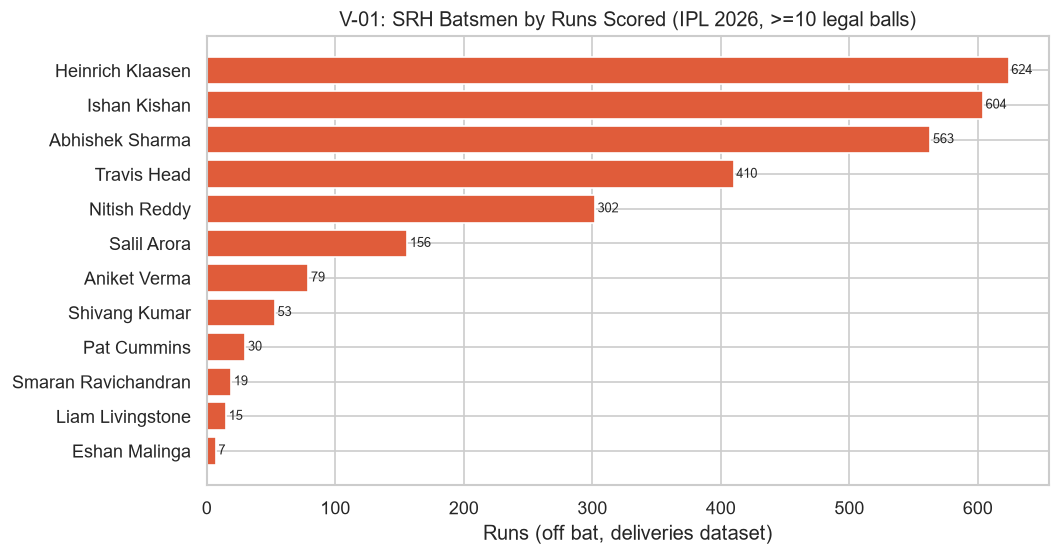

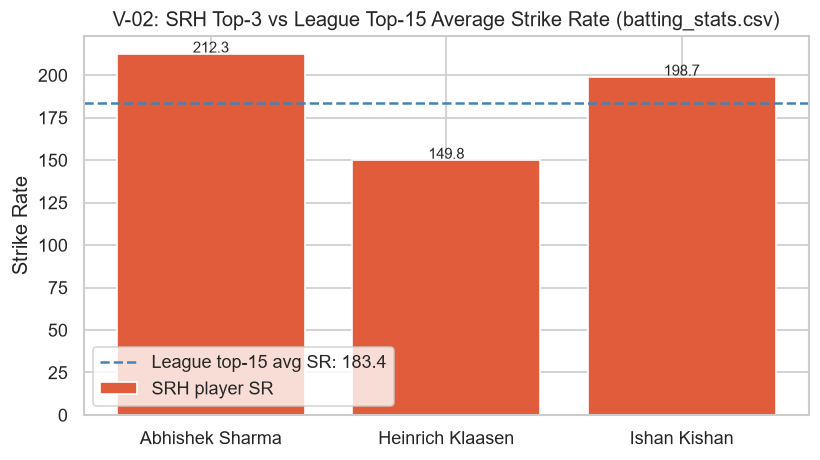

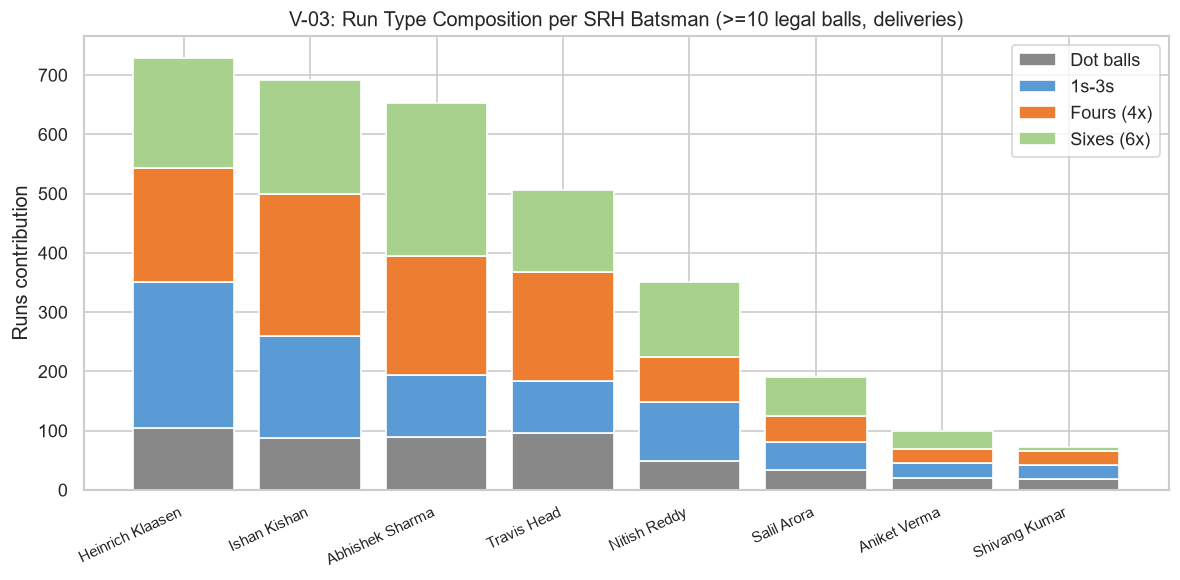

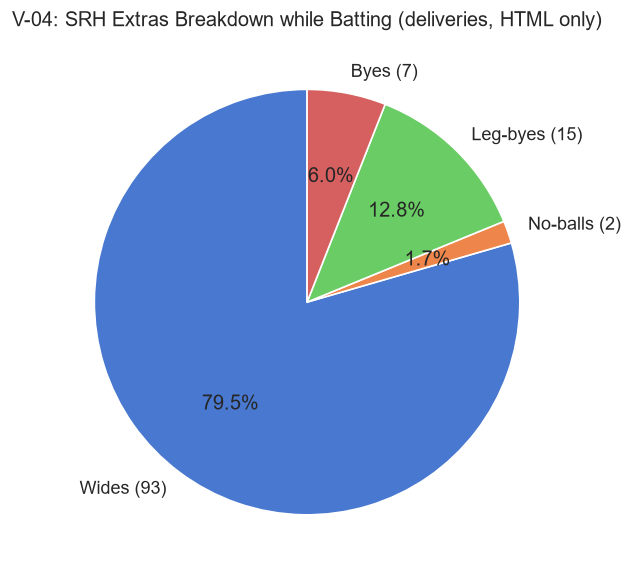

In [119]:
# V-01: SRH Batsmen by Runs Scored
top_bat = bat_stats[bat_stats['legal_balls'] >= 10].sort_values('runs', ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(top_bat)*0.4)))
bars = ax.barh(top_bat['striker'], top_bat['runs'], color='#E05C3A')
ax.set_xlabel('Runs (off bat, deliveries dataset)')
ax.set_title('V-01: SRH Batsmen by Runs Scored (IPL 2026, >=10 legal balls)')
for bar, val in zip(bars, top_bat['runs']):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(VISUALS / 'V-01_srh_batsmen_runs.png', dpi=150, bbox_inches='tight')
plt.show()

# V-02: SRH vs League Strike Rate
srh_sr  = df_srh_bat_stats[['batsman','strike_rate']].copy()
lg_avg_sr = df_bat['strike_rate'].mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(srh_sr['batsman'], srh_sr['strike_rate'], color='#E05C3A', label='SRH player SR')
ax.axhline(lg_avg_sr, color='steelblue', linestyle='--', label=f'League top-15 avg SR: {lg_avg_sr:.1f}')
ax.set_ylabel('Strike Rate')
ax.set_title('V-02: SRH Top-3 vs League Top-15 Average Strike Rate (batting_stats.csv)')
ax.legend()
for i, row in srh_sr.iterrows():
    ax.text(list(srh_sr['batsman']).index(row['batsman']), row['strike_rate']+1,
            f"{row['strike_rate']:.1f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(VISUALS / 'V-02_srh_vs_league_strike_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# V-03: Run Type Composition per batsman (dots / 1s-3s / 4s / 6s)
top6 = bat_stats[bat_stats['legal_balls']>=10].sort_values('runs',ascending=False).head(8)
top6 = top6.copy()
top6['singles_to_3s'] = top6['runs'] - 4*top6['fours'] - 6*top6['sixes']
top6['singles_to_3s'] = top6['singles_to_3s'].clip(lower=0)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top6))
w = 0.6
ax.bar(x, top6['dots'],                              label='Dot balls',   color='#888')
ax.bar(x, top6['singles_to_3s'], bottom=top6['dots'],label='1s-3s',       color='#5B9BD5')
ax.bar(x, 4*top6['fours'],   bottom=top6['dots']+top6['singles_to_3s'], label='Fours (4x)', color='#ED7D31')
ax.bar(x, 6*top6['sixes'],   bottom=top6['dots']+top6['singles_to_3s']+4*top6['fours'], label='Sixes (6x)', color='#A9D18E')
ax.set_xticks(x)
ax.set_xticklabels(top6['striker'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Runs contribution')
ax.set_title('V-03: Run Type Composition per SRH Batsman (>=10 legal balls, deliveries)')
ax.legend()
plt.tight_layout()
plt.savefig(VISUALS / 'V-03_run_type_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# V-04: Extras breakdown pie (HTML only)
ext_vals = [df_srh_bat_del[c].sum() for c in ['wide','noballs','legbyes','byes']]
ext_lbls = ['Wides','No-balls','Leg-byes','Byes']
fig, ax = plt.subplots(figsize=(6,5))
ax.pie(ext_vals, labels=[f'{l} ({v})' for l,v in zip(ext_lbls,ext_vals)], autopct='%1.1f%%', startangle=90)
ax.set_title('V-04: SRH Extras Breakdown while Batting (deliveries, HTML only)')
plt.tight_layout()
plt.savefig(VISUALS / 'V-04_extras_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Bowling Analysis

SRH bowling from deliveries and `bowling.csv`.  
`Best Figures` column excluded from every output. Economy denominator = legal deliveries / 6.

In [120]:
# 7a. Overall SRH bowling totals
# Bowling runs conceded = runs_of_bat + wides + no-ball runs.
# Byes and leg-byes are EXCLUDED (charged to the fielding side, not the bowler).
# Economy denominator = legal deliveries (wides and no-balls excluded) / 6.
srh_bowl_legal   = df_srh_bowl_del['is_legal_delivery'].sum()
srh_bowl_bat_runs= df_srh_bowl_del['runs_of_bat'].sum()
srh_bowl_wides   = df_srh_bowl_del['wide'].sum()
srh_bowl_noballs = df_srh_bowl_del['noballs'].sum()
# bowl_extras = wides + no-ball runs only (byes and leg-byes excluded)
srh_bowl_extras  = (df_srh_bowl_del['wide'] + df_srh_bowl_del['noballs']).sum()
srh_bowl_total   = srh_bowl_bat_runs + srh_bowl_extras
srh_bowl_overs   = srh_bowl_legal / 6
srh_bowl_econ    = srh_bowl_total / srh_bowl_overs
srh_wkts_taken_n = df_srh_bowl_del['wicket_type'].notna().sum()

print('SRH Overall Bowling Totals')
print(f'  Legal deliveries           : {srh_bowl_legal:,}')
print(f'  Overs (legal/6)            : {srh_bowl_overs:.2f}')
print(f'  Runs off bat conceded      : {srh_bowl_bat_runs:,}')
print(f'  Wides conceded             : {srh_bowl_wides:,}')
print(f'  No-ball runs conceded      : {srh_bowl_noballs:,}')
print(f'  Bowl extras (wides+nb)     : {srh_bowl_extras:,}  [byes/leg-byes excluded]')
print(f'  Total runs conceded        : {srh_bowl_total:,}  [runs_of_bat + wides + nb]')
print(f'  Bowling economy            : {srh_bowl_econ:.2f}')
print(f'  Wickets taken              : {srh_wkts_taken_n}')

SRH Overall Bowling Totals
  Legal deliveries           : 1,727
  Overs (legal/6)            : 287.83
  Runs off bat conceded      : 2,780
  Wides conceded             : 85
  No-ball runs conceded      : 7
  Bowl extras (wides+nb)     : 92  [byes/leg-byes excluded]
  Total runs conceded        : 2,872  [runs_of_bat + wides + nb]
  Bowling economy            : 9.98
  Wickets taken              : 96


In [121]:
# 7b. Per-bowler breakdown
bowl_grp = df_srh_bowl_del.groupby('bowler')
bowl_stats = pd.DataFrame({
    'legal_del': bowl_grp.apply(lambda g: g['is_legal_delivery'].sum()),
    'runs_con':  bowl_grp.apply(lambda g: g['runs_of_bat'].sum() +
                                (g['wide']+g['noballs']).sum()),
    'wickets':   bowl_grp['wicket_type'].apply(lambda s: s.notna().sum()),
    'wides':     bowl_grp['wide'].sum(),
    'noballs':   bowl_grp['noballs'].sum(),
    'dots':      bowl_grp.apply(lambda g: (g['is_legal_delivery'] & (g['runs_of_bat']==0) &
                                           (g['wide']==0)).sum()),
}).reset_index()
bowl_stats['overs']   = (bowl_stats['legal_del'] / 6).round(2)
bowl_stats['economy'] = (bowl_stats['runs_con'] / (bowl_stats['legal_del']/6)).round(2)
bowl_stats['dot_pct'] = (bowl_stats['dots'] / bowl_stats['legal_del'] * 100).round(1)
bowl_stats = bowl_stats[bowl_stats['legal_del']>=6].sort_values('wickets',ascending=False).reset_index(drop=True)

print(f'SRH bowlers (>=6 legal deliveries, N={len(bowl_stats)}):')
display(bowl_stats)

SRH bowlers (>=6 legal deliveries, N=13):


,bowler,legal_del,runs_con,wickets,wides,noballs,dots,overs,economy,dot_pct
0,Eshan Malinga,326,505,21,23,0,117,54.33,9.29,35.9
1,Sakib Hussain,252,392,16,20,1,87,42.00,9.33,34.5
2,Praful Hinge,156,303,14,7,3,62,26.00,11.65,39.7
3,Shivang Kumar,233,373,11,5,0,63,38.83,9.61,27.0
4,Nitish Reddy,186,323,9,10,1,57,31.00,10.42,30.6
5,Pat Cummins,192,301,8,7,2,70,32.00,9.41,36.5
6,Harsh Dubey,132,226,8,6,0,38,22.00,10.27,28.8
7,Jaydev Unadkat,77,140,4,1,0,23,12.83,10.91,29.9
8,David Payne,30,70,2,1,0,5,5.00,14.00,16.7
9,Harshal Patel,84,148,1,2,0,18,14.00,10.57,21.4


In [122]:
# 7c. bowling.csv contextualisation -- Best Figures excluded
BOWL_COLS = [c for c in df_bowl.columns if c != 'Best Figures']
print('SRH players in bowling.csv (n=2 of 15). Best Figures column excluded.')
display(df_srh_bowl_stats[BOWL_COLS])

league_econ = df_bowl['Economy'].mean()
srh_econ_csv = df_srh_bowl_stats['Economy'].mean()
print(f'\nLeague top-15 avg Economy : {league_econ:.2f}  (n=15)')
print(f'SRH top-2 avg Economy     : {srh_econ_csv:.2f}  (n=2)')

SRH players in bowling.csv (n=2 of 15). Best Figures column excluded.


,Rank,Player,Team,Matches,Overs,Runs,Wickets,Average,Economy,team
5,6,Eshan Malinga,Sunrisers Hyderabad,15,54.2,507,20,25.35,9.33,SRH
13,14,Sakib Hussain,Sunrisers Hyderabad,11,42.0,397,15,26.47,9.45,SRH



League top-15 avg Economy : 9.11  (n=15)
SRH top-2 avg Economy     : 9.39  (n=2)


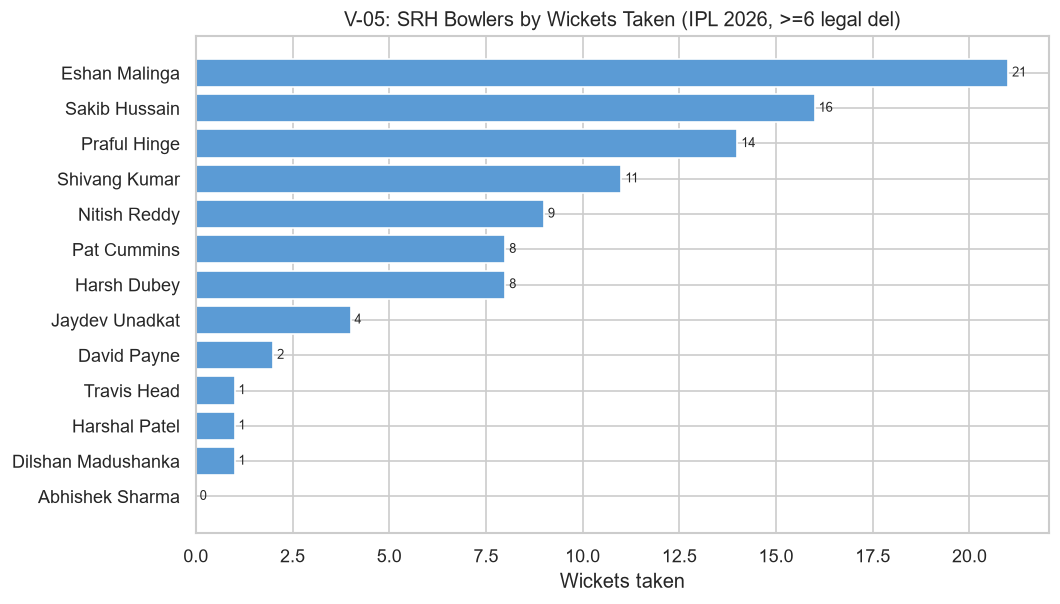

C:\Users\lanka\AppData\Local\Temp\ipykernel_1008\464791742.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(bowl_econ_df['Player'], rotation=40, ha='right', fontsize=8)


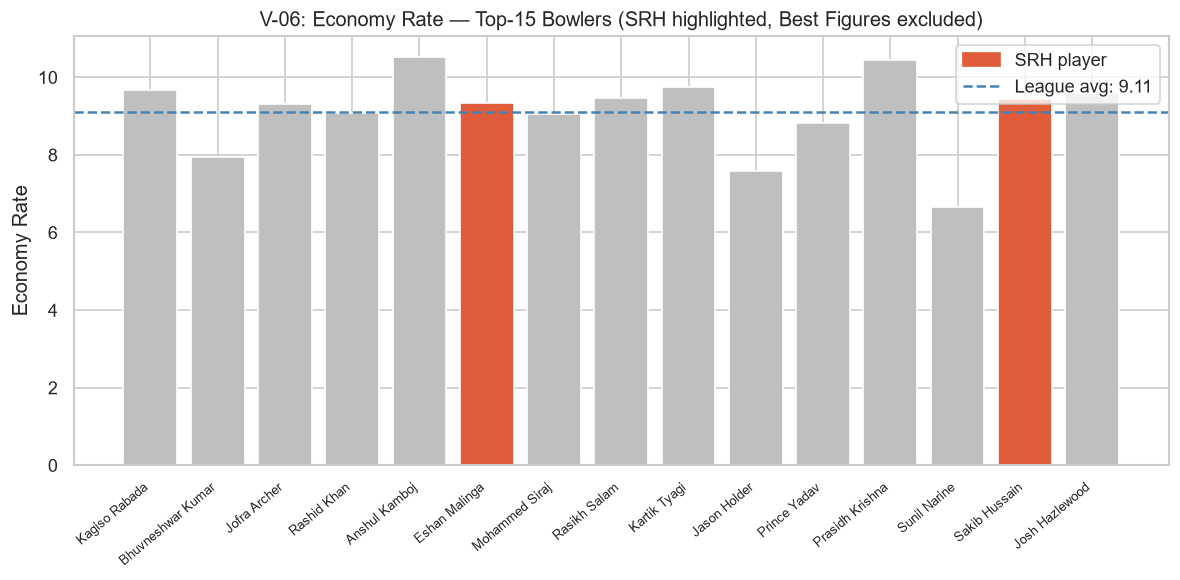

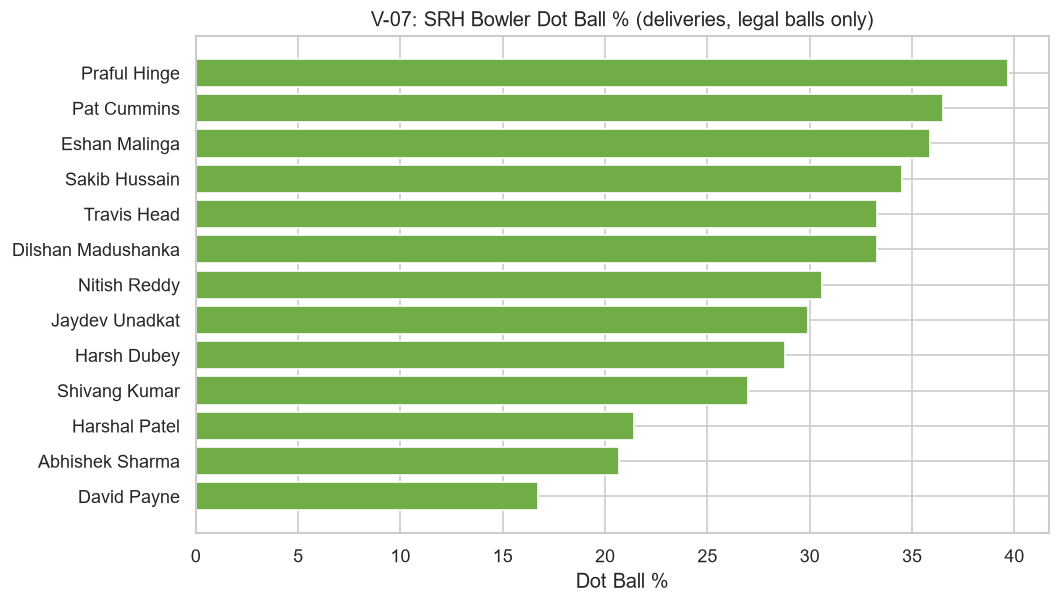

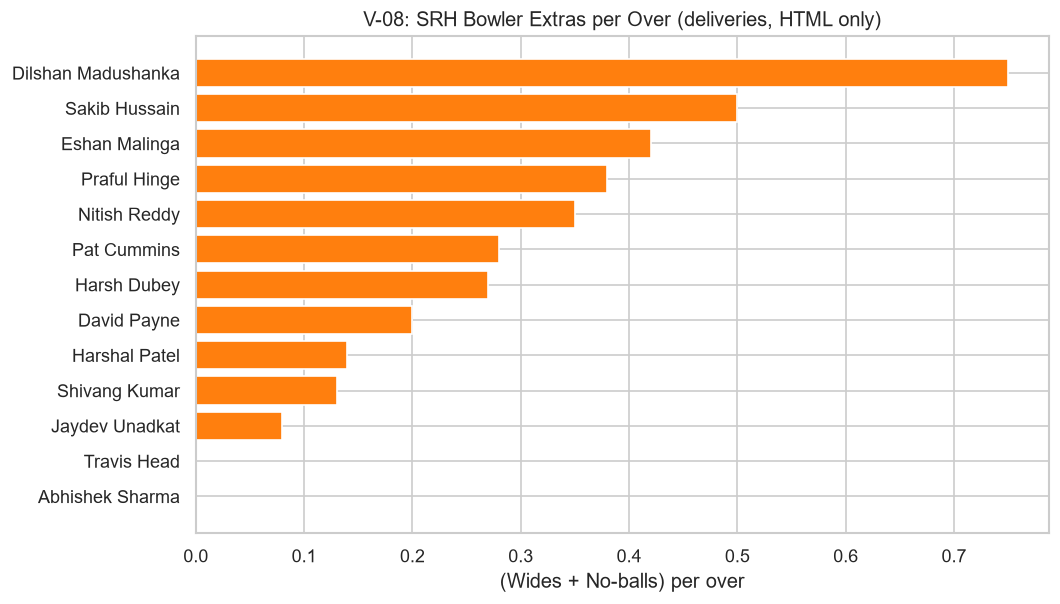

In [123]:
# V-05: SRH Bowlers by Wickets
top_bowl = bowl_stats.sort_values('wickets', ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(top_bowl)*0.4)))
bars = ax.barh(top_bowl['bowler'], top_bowl['wickets'], color='#5B9BD5')
ax.set_xlabel('Wickets taken')
ax.set_title('V-05: SRH Bowlers by Wickets Taken (IPL 2026, >=6 legal del)')
for bar, val in zip(bars, top_bowl['wickets']):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2, str(int(val)), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(VISUALS / 'V-05_srh_bowlers_wickets.png', dpi=150, bbox_inches='tight')
plt.show()

# V-06: Economy rate comparison -- bowling.csv (Best Figures excluded)
bowl_econ_df = df_bowl[['Player','Economy','team']].copy()
srh_mask = bowl_econ_df['team'] == 'SRH'
colors = ['#E05C3A' if s else '#BFBFBF' for s in srh_mask]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bowl_econ_df['Player'], bowl_econ_df['Economy'], color=colors)
ax.axhline(league_econ, color='steelblue', linestyle='--', label=f'League avg: {league_econ:.2f}')
ax.set_ylabel('Economy Rate')
ax.set_title('V-06: Economy Rate — Top-15 Bowlers (SRH highlighted, Best Figures excluded)')
ax.set_xticklabels(bowl_econ_df['Player'], rotation=40, ha='right', fontsize=8)
ax.legend()
srh_patch = mpatches.Patch(color='#E05C3A', label='SRH player')
ax.legend(handles=[srh_patch, plt.Line2D([0],[0],color='steelblue',linestyle='--',
          label=f'League avg: {league_econ:.2f}')])
plt.tight_layout()
plt.savefig(VISUALS / 'V-06_economy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# V-07: SRH Bowler Dot Ball %
db_df = bowl_stats.sort_values('dot_pct', ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(db_df)*0.4)))
ax.barh(db_df['bowler'], db_df['dot_pct'], color='#70AD47')
ax.set_xlabel('Dot Ball %')
ax.set_title('V-07: SRH Bowler Dot Ball % (deliveries, legal balls only)')
plt.tight_layout()
plt.savefig(VISUALS / 'V-07_dot_ball_pct.png', dpi=150, bbox_inches='tight')
plt.show()

# V-08: Extras per over per bowler (HTML only)
bowl_stats['extras_po'] = ((bowl_stats['wides']+bowl_stats['noballs']) /
                            bowl_stats['overs'].replace(0,np.nan)).round(2)
epo_df = bowl_stats.sort_values('extras_po', ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(epo_df)*0.4)))
ax.barh(epo_df['bowler'], epo_df['extras_po'], color='#FF7F0E')
ax.set_xlabel('(Wides + No-balls) per over')
ax.set_title('V-08: SRH Bowler Extras per Over (deliveries, HTML only)')
plt.tight_layout()
plt.savefig(VISUALS / 'V-08_extras_per_over.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: Fielding Analysis

> **Data limitation:** `fielding_stats.csv` records catches only. The `fielder` column in deliveries
> is populated only for caught, stumped, and some run-out dismissals. Fielding analysis is limited
> to catch statistics and fielder-involvement counts from wicket deliveries.

In [124]:
# 8a. Fielding stats summary
print('SRH fielding stats (top-15 catch leaders only):')
display(df_srh_field_stats)

league_cpm = df_field['cpm'].mean()
srh_cpm    = df_srh_field_stats['cpm'].mean()
print(f'\nLeague top-15 avg cpm : {league_cpm:.3f}  (n=15)')
print(f'SRH top-2 avg cpm     : {srh_cpm:.3f}  (n=2)')
print('Note: covers top-15 catch leaders only.')

# 8b. Fielder involvement from deliveries
srh_wkts_del = df_srh_bowl_del[df_srh_bowl_del['wicket_type'].notna()]
fielder_inv = (srh_wkts_del[srh_wkts_del['fielder'].notna()]
               .groupby('fielder').size().sort_values(ascending=False).reset_index(name='involvements'))
print(f'\nFielder involvements in SRH bowling wickets (fielder column non-null, n={len(srh_wkts_del[srh_wkts_del["fielder"].notna()])}):')
display(fielder_inv)

# 8c. Run-out count
runout_n = (df_srh_bowl_del['wicket_type'] == 'runout').sum()
total_srh_wkts = df_srh_bowl_del['wicket_type'].notna().sum()
print(f'\nRun-outs in SRH bowling: {runout_n} of {total_srh_wkts} total wickets ({100*runout_n/total_srh_wkts:.1f}%)')

SRH fielding stats (top-15 catch leaders only):


,rank,player,team,matches,catches,cpm
6,7,Heinrich Klaasen,SRH,8,7,0.875
7,8,Nitish Kumar Reddy,SRH,8,7,0.875



League top-15 avg cpm : 0.956  (n=15)
SRH top-2 avg cpm     : 0.875  (n=2)
Note: covers top-15 catch leaders only.

Fielder involvements in SRH bowling wickets (fielder column non-null, n=81):


,fielder,involvements
0,Heinrich Klaasen,13
1,Ishan Kishan,10
2,Abhishek Sharma,10
3,Nitish Reddy,10
4,Aniket Verma,5
5,Eshan Malinga,5
6,Liam Livingstone,4
7,Harsh Dubey,4
8,Salil Arora,3
9,Jaydev Unadkat,3



Run-outs in SRH bowling: 5 of 96 total wickets (5.2%)


C:\Users\lanka\AppData\Local\Temp\ipykernel_1008\3919668427.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(all_field['player'], rotation=40, ha='right', fontsize=8)


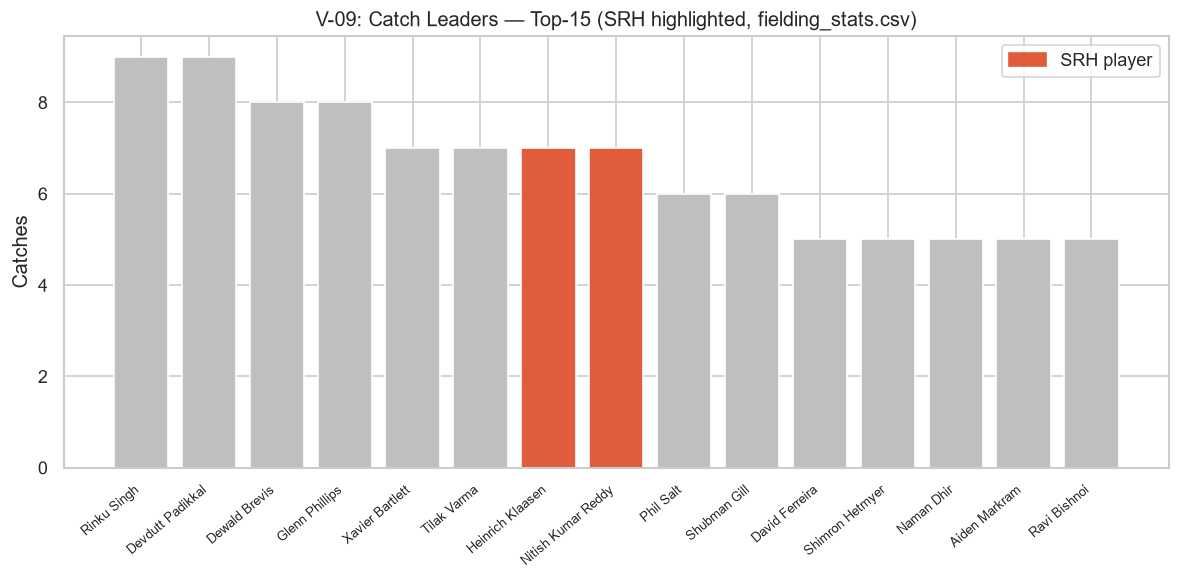

C:\Users\lanka\AppData\Local\Temp\ipykernel_1008\3919668427.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(df_field['player'], rotation=40, ha='right', fontsize=8)


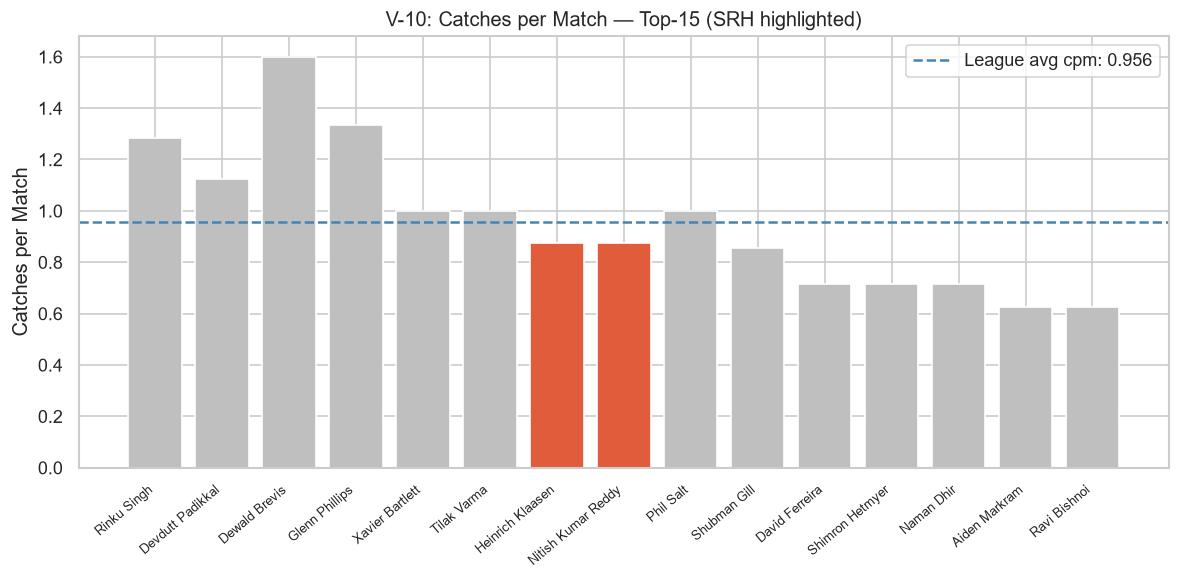

In [125]:
# V-09: SRH vs League Catch Leaders
all_field = df_field[['player','catches','team']].copy()
colors9 = ['#E05C3A' if t=='SRH' else '#BFBFBF' for t in all_field['team']]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(all_field['player'], all_field['catches'], color=colors9)
ax.set_ylabel('Catches')
ax.set_title('V-09: Catch Leaders — Top-15 (SRH highlighted, fielding_stats.csv)')
ax.set_xticklabels(all_field['player'], rotation=40, ha='right', fontsize=8)
srh_p = mpatches.Patch(color='#E05C3A', label='SRH player')
ax.legend(handles=[srh_p])
plt.tight_layout()
plt.savefig(VISUALS / 'V-09_srh_catch_leaders.png', dpi=150, bbox_inches='tight')
plt.show()

# V-10: Catches Per Match comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors10 = ['#E05C3A' if t=='SRH' else '#BFBFBF' for t in df_field['team']]
ax.bar(df_field['player'], df_field['cpm'], color=colors10)
ax.axhline(league_cpm, color='steelblue', linestyle='--', label=f'League avg cpm: {league_cpm:.3f}')
ax.set_ylabel('Catches per Match')
ax.set_title('V-10: Catches per Match — Top-15 (SRH highlighted)')
ax.set_xticklabels(df_field['player'], rotation=40, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(VISUALS / 'V-10_cpm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8: Phase Analysis (Powerplay / Middle / Death)

SRH batting and bowling by phase vs. tournament-wide benchmarks.  
Sample sizes stated for every metric.

In [126]:
# 9a. SRH batting by phase
def phase_bat_summary(df, label):
    grp = df.groupby('phase')
    result = pd.DataFrame({
        'legal_balls': grp.apply(lambda g: g['is_legal_delivery'].sum()),
        'runs':        grp['runs_of_bat'].sum(),
        'fours':       grp.apply(lambda g: (g['runs_of_bat']==4).sum()),
        'sixes':       grp.apply(lambda g: (g['runs_of_bat']==6).sum()),
        'dots':        grp.apply(lambda g: (g['is_legal_delivery']&(g['runs_of_bat']==0)).sum()),
        'wickets':     grp['wicket_type'].apply(lambda s: s.notna().sum()),
    }).reset_index()
    result['run_rate'] = (result['runs'] / (result['legal_balls']/6)).round(2)
    result['boundary_pct'] = ((result['fours']+result['sixes'])/result['legal_balls']*100).round(1)
    result['dot_pct']  = (result['dots']/result['legal_balls']*100).round(1)
    result.attrs['label'] = label
    return result

srh_bat_phase  = phase_bat_summary(df_srh_bat_del,  'SRH batting')
all_bat_phase  = phase_bat_summary(df_del,           'Tournament batting (all teams)')
phase_order    = ['Powerplay','Middle','Death']
srh_bat_phase  = srh_bat_phase.set_index('phase').reindex(phase_order)
all_bat_phase  = all_bat_phase.set_index('phase').reindex(phase_order)

print('SRH batting by phase:')
display(srh_bat_phase)
print('\nTournament batting by phase (all teams):')
display(all_bat_phase)

SRH batting by phase:


,legal_balls,runs,fours,sixes,dots,wickets,run_rate,boundary_pct,dot_pct
phase,,,,,,,,,
Powerplay,540,943,105,59,230,24,10.48,30.4,42.6
Middle,894,1431,109,77,243,45,9.60,20.8,27.2
Death,303,529,41,35,97,33,10.48,25.1,32.0



Tournament batting by phase (all teams):


,legal_balls,runs,fours,sixes,dots,wickets,run_rate,boundary_pct,dot_pct
phase,,,,,,,,,
Powerplay,5282,8424,964,455,2274,240,9.57,26.9,43.1
Middle,8581,12880,981,669,2558,411,9.01,19.2,29.8
Death,2806,4849,388,302,854,228,10.37,24.6,30.4


In [127]:
# 9b. SRH bowling by phase
def phase_bowl_summary(df, label):
    grp = df.groupby('phase')
    result = pd.DataFrame({
        'legal_del': grp.apply(lambda g: g['is_legal_delivery'].sum()),
        'runs_con':  grp.apply(lambda g: g['runs_of_bat'].sum()+(g['wide']+g['noballs']).sum()),
        'wickets':   grp['wicket_type'].apply(lambda s: s.notna().sum()),
    }).reset_index()
    result['economy']  = (result['runs_con']/(result['legal_del']/6)).round(2)
    result['bpw']      = (result['legal_del']/result['wickets'].replace(0,np.nan)).round(1)
    result.attrs['label'] = label
    return result

srh_bowl_phase = phase_bowl_summary(df_srh_bowl_del, 'SRH bowling')
all_bowl_phase = phase_bowl_summary(df_del,           'Tournament bowling (all teams)')
srh_bowl_phase = srh_bowl_phase.set_index('phase').reindex(phase_order)
all_bowl_phase = all_bowl_phase.set_index('phase').reindex(phase_order)

print('SRH bowling by phase:')
display(srh_bowl_phase)
print('\nTournament bowling by phase (all teams):')
display(all_bowl_phase)

SRH bowling by phase:


,legal_del,runs_con,wickets,economy,bpw
phase,,,,,
Powerplay,540,979,25,10.88,21.6
Middle,898,1446,43,9.66,20.9
Death,289,447,28,9.28,10.3



Tournament bowling by phase (all teams):


,legal_del,runs_con,wickets,economy,bpw
phase,,,,,
Powerplay,5282,8665,240,9.84,22.0
Middle,8581,13251,411,9.27,20.9
Death,2806,5045,228,10.79,12.3


In [128]:
# 9d. Over-by-over profile
def over_rr(df):
    g = df.groupby('over_number')
    runs  = g['runs_of_bat'].sum()
    legal = g.apply(lambda x: x['is_legal_delivery'].sum())
    return (runs / (legal/6)).round(2)

srh_bat_ovo  = over_rr(df_srh_bat_del)
srh_bowl_ovo = over_rr(df_srh_bowl_del)
print('SRH batting run rate over-by-over (averaged across all 15 matches):')
display(srh_bat_ovo.to_frame('run_rate'))

SRH batting run rate over-by-over (averaged across all 15 matches):


,run_rate
over_number,
0,7.40
1,9.93
2,11.73
3,9.53
4,12.20
5,12.07
6,9.27
7,9.07
8,8.73


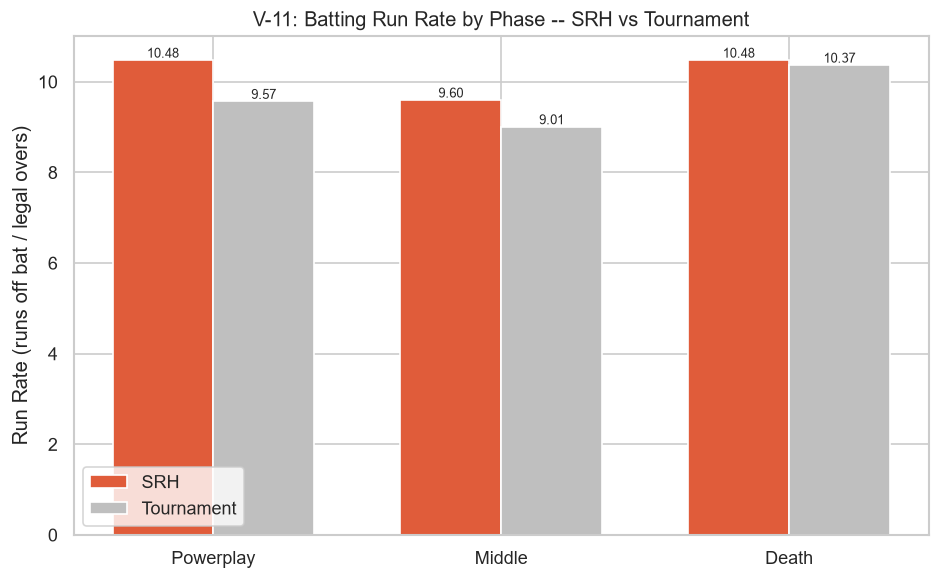

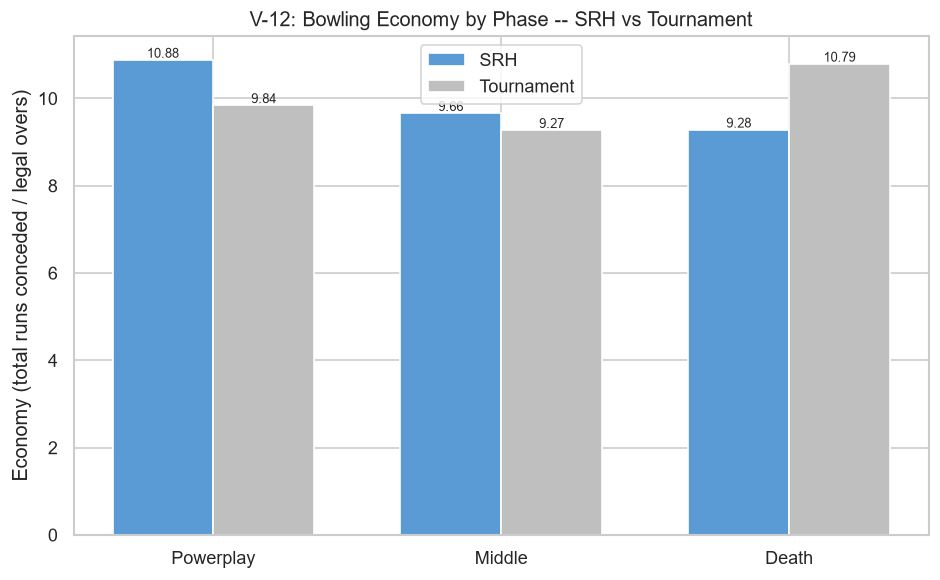

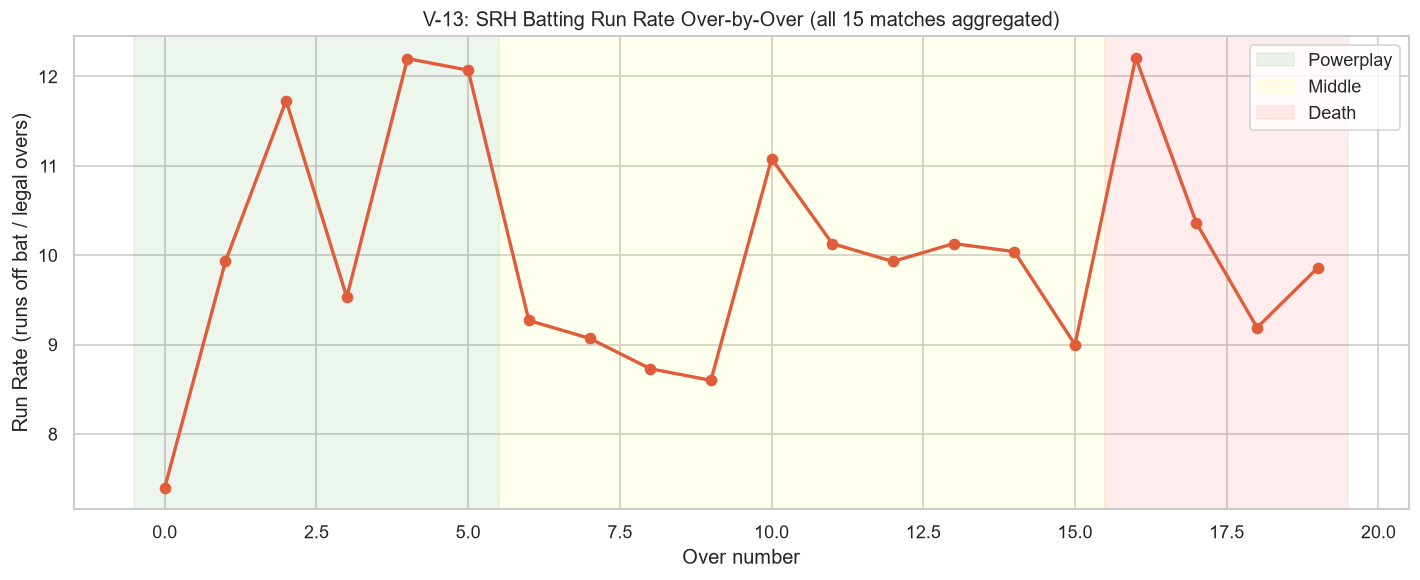

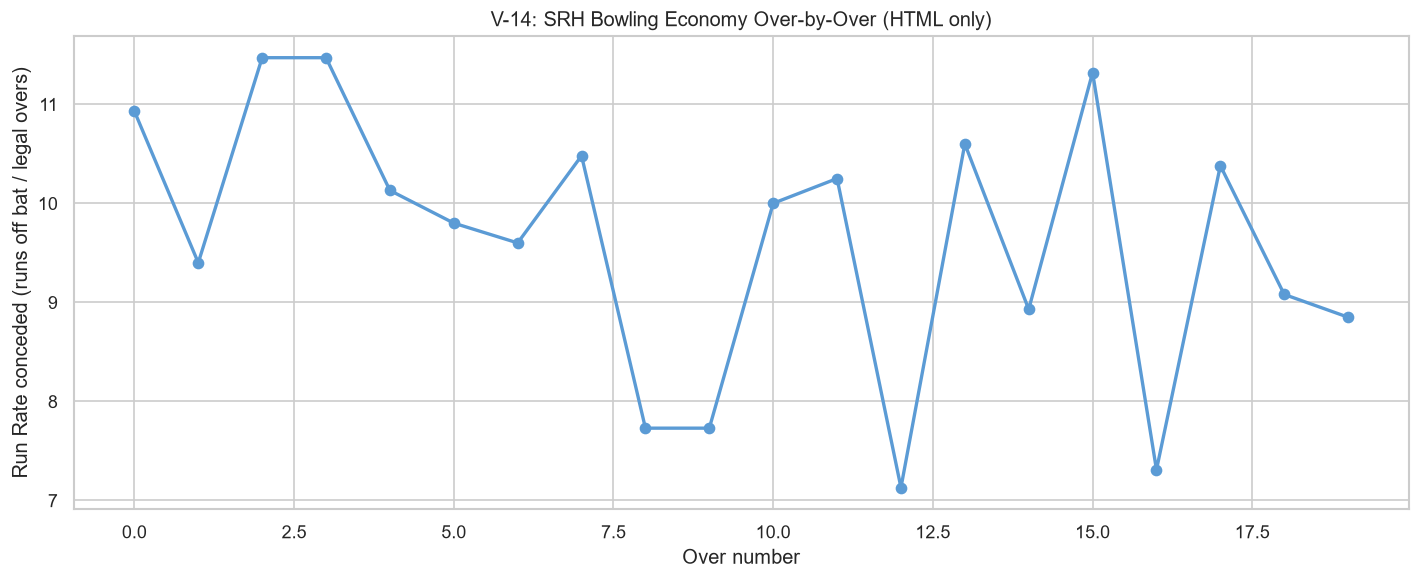

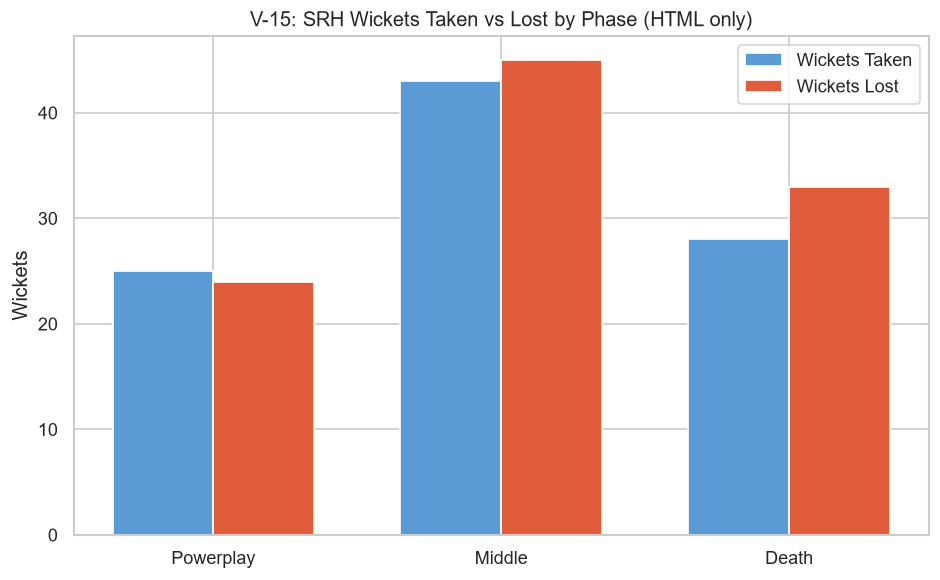

In [129]:
# V-11: Batting Run Rate by Phase -- SRH vs Tournament
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(phase_order)); w = 0.35
ax.bar(x-w/2, srh_bat_phase['run_rate'],   w, label='SRH',        color='#E05C3A')
ax.bar(x+w/2, all_bat_phase['run_rate'],   w, label='Tournament', color='#BFBFBF')
ax.set_xticks(x); ax.set_xticklabels(phase_order)
ax.set_ylabel('Run Rate (runs off bat / legal overs)')
ax.set_title('V-11: Batting Run Rate by Phase -- SRH vs Tournament')
ax.legend()
for i,(s,t) in enumerate(zip(srh_bat_phase['run_rate'],all_bat_phase['run_rate'])):
    ax.text(i-w/2, s+0.05, f'{s:.2f}', ha='center', fontsize=8)
    ax.text(i+w/2, t+0.05, f'{t:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(VISUALS / 'V-11_batting_rr_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()

# V-12: Bowling Economy by Phase -- SRH vs Tournament
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x-w/2, srh_bowl_phase['economy'], w, label='SRH',        color='#5B9BD5')
ax.bar(x+w/2, all_bowl_phase['economy'], w, label='Tournament', color='#BFBFBF')
ax.set_xticks(x); ax.set_xticklabels(phase_order)
ax.set_ylabel('Economy (total runs conceded / legal overs)')
ax.set_title('V-12: Bowling Economy by Phase -- SRH vs Tournament')
ax.legend()
for i,(s,t) in enumerate(zip(srh_bowl_phase['economy'],all_bowl_phase['economy'])):
    ax.text(i-w/2, s+0.05, f'{s:.2f}', ha='center', fontsize=8)
    ax.text(i+w/2, t+0.05, f'{t:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(VISUALS / 'V-12_bowling_economy_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()

# V-13: SRH batting run rate over-by-over
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(srh_bat_ovo.index, srh_bat_ovo.values, marker='o', color='#E05C3A', lw=2)
ax.axvspan(-0.5, 5.5,  alpha=0.07, color='green',  label='Powerplay')
ax.axvspan(5.5,  15.5, alpha=0.07, color='yellow', label='Middle')
ax.axvspan(15.5, 19.5, alpha=0.07, color='red',    label='Death')
ax.set_xlabel('Over number')
ax.set_ylabel('Run Rate (runs off bat / legal overs)')
ax.set_title('V-13: SRH Batting Run Rate Over-by-Over (all 15 matches aggregated)')
ax.legend()
plt.tight_layout()
plt.savefig(VISUALS / 'V-13_ovo_batting_rr.png', dpi=150, bbox_inches='tight')
plt.show()

# V-14: SRH bowling economy over-by-over (HTML only)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(srh_bowl_ovo.index, srh_bowl_ovo.values, marker='o', color='#5B9BD5', lw=2)
ax.set_xlabel('Over number')
ax.set_ylabel('Run Rate conceded (runs off bat / legal overs)')
ax.set_title('V-14: SRH Bowling Economy Over-by-Over (HTML only)')
plt.tight_layout()
plt.savefig(VISUALS / 'V-14_ovo_bowling_economy.png', dpi=150, bbox_inches='tight')
plt.show()

# V-15: Wickets per phase taken vs lost (HTML only)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x-w/2, srh_bowl_phase['wickets'], w, label='Wickets Taken', color='#5B9BD5')
wkts_lost_phase = (df_srh_bat_del.groupby('phase')['wicket_type']
                   .apply(lambda s: s.notna().sum()).reindex(phase_order))
ax.bar(x+w/2, wkts_lost_phase.values, w, label='Wickets Lost', color='#E05C3A')
ax.set_xticks(x); ax.set_xticklabels(phase_order)
ax.set_ylabel('Wickets')
ax.set_title('V-15: SRH Wickets Taken vs Lost by Phase (HTML only)')
ax.legend()
plt.tight_layout()
plt.savefig(VISUALS / 'V-15_wickets_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9: Wicket Pattern Analysis

Dismissal type breakdown for SRH bowling and batting. All percentages with sample sizes.

In [130]:
# 10a. SRH wickets taken
srh_wkts_taken = df_srh_bowl_del[df_srh_bowl_del['wicket_type'].notna()].copy()
wkt_taken_vc   = srh_wkts_taken['wicket_type'].value_counts().reset_index()
wkt_taken_vc.columns = ['wicket_type','count']
wkt_taken_vc['pct'] = (wkt_taken_vc['count']/wkt_taken_vc['count'].sum()*100).round(1)
print(f'SRH wickets taken (n={len(srh_wkts_taken)}):')
display(wkt_taken_vc)

# 10c. SRH wickets lost
srh_wkts_lost = df_srh_bat_del[df_srh_bat_del['wicket_type'].notna()].copy()
wkt_lost_vc   = srh_wkts_lost['wicket_type'].value_counts().reset_index()
wkt_lost_vc.columns = ['wicket_type','count']
wkt_lost_vc['pct'] = (wkt_lost_vc['count']/wkt_lost_vc['count'].sum()*100).round(1)
print(f'\nSRH wickets lost (n={len(srh_wkts_lost)}):')
display(wkt_lost_vc)

SRH wickets taken (n=96):


,wicket_type,count,pct
0,caught,79,82.3
1,bowled,10,10.4
2,runout,5,5.2
3,stumped,1,1.0
4,lbw,1,1.0



SRH wickets lost (n=102):


,wicket_type,count,pct
0,caught,81,79.4
1,bowled,14,13.7
2,runout,3,2.9
3,lbw,2,2.0
4,stumped,2,2.0


In [131]:
# 10b. Per-bowler wicket breakdown
bowler_wkt = (srh_wkts_taken.groupby(['bowler','wicket_type'])
              .size().unstack(fill_value=0))
bowler_wkt['total'] = bowler_wkt.sum(axis=1)
bowler_wkt = bowler_wkt.sort_values('total', ascending=False)
print('SRH bowler x wicket-type matrix:')
display(bowler_wkt)

# 10d. Per-batsman dismissal record
bat_dism = (srh_wkts_lost.groupby('player_dismissed')['wicket_type']
            .agg(['count', lambda s: s.mode().iloc[0] if len(s)>0 else 'N/A'])
            .rename(columns={'count':'dismissals','<lambda_0>':'most_common_type'})
            .sort_values('dismissals', ascending=False))
print('SRH batsmen dismissal records:')
display(bat_dism)

# 10e. Phase-wise wicket distribution
phase_wkt_taken = (srh_wkts_taken.groupby('phase').size().reindex(phase_order).fillna(0).astype(int))
phase_wkt_lost  = (srh_wkts_lost.groupby('phase').size().reindex(phase_order).fillna(0).astype(int))
print('\nSRH wickets taken by phase:', phase_wkt_taken.to_dict())
print('SRH wickets lost by phase: ', phase_wkt_lost.to_dict())

# 10f. Opposition breakdown
opp_wkts = srh_wkts_taken.groupby('batting_team').size().sort_values(ascending=False)
print('\nSRH wickets taken vs each opponent:')
print(opp_wkts.to_string())
print('Caveat: reflects both bowling performance and fixture schedule.')

SRH bowler x wicket-type matrix:


wicket_type,bowled,caught,lbw,runout,stumped,total
bowler,,,,,,
Eshan Malinga,2,18,0,1,0,21
Sakib Hussain,4,10,1,1,0,16
Praful Hinge,1,13,0,0,0,14
Shivang Kumar,0,9,0,2,0,11
Nitish Reddy,0,8,0,1,0,9
Pat Cummins,1,7,0,0,0,8
Harsh Dubey,1,6,0,0,1,8
Jaydev Unadkat,1,3,0,0,0,4
David Payne,0,2,0,0,0,2


SRH batsmen dismissal records:


,dismissals,most_common_type
player_dismissed,,
Ishan Kishan,15,caught
Travis Head,15,caught
Abhishek Sharma,14,caught
Heinrich Klaasen,13,caught
Nitish Reddy,10,caught
Salil Arora,7,caught
Shivang Kumar,6,caught
Aniket Verma,5,caught
Pat Cummins,3,caught



SRH wickets taken by phase: {'Powerplay': 25, 'Middle': 43, 'Death': 28}
SRH wickets lost by phase:  {'Powerplay': 24, 'Middle': 45, 'Death': 33}

SRH wickets taken vs each opponent:
batting_team
RR      24
CSK     15
KKR     13
PBKS    11
DC       9
RCB      9
GT       5
LSG      5
MI       5
Caveat: reflects both bowling performance and fixture schedule.


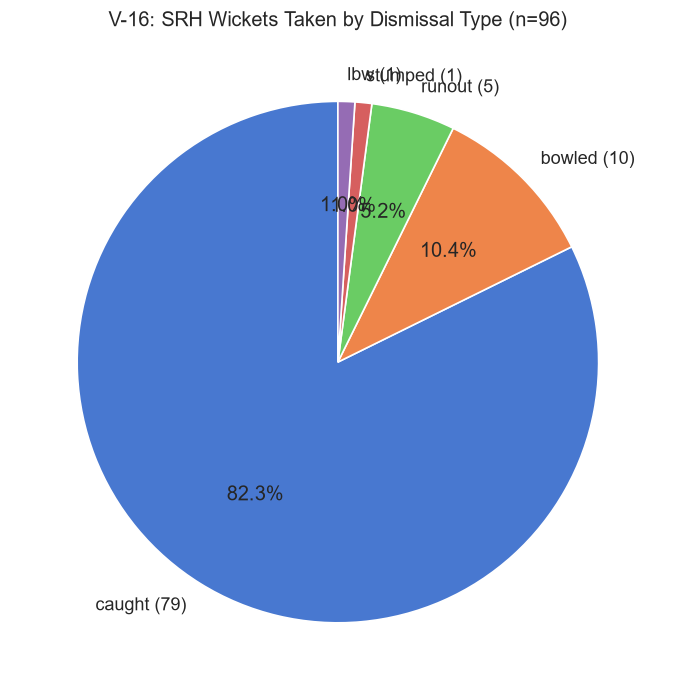

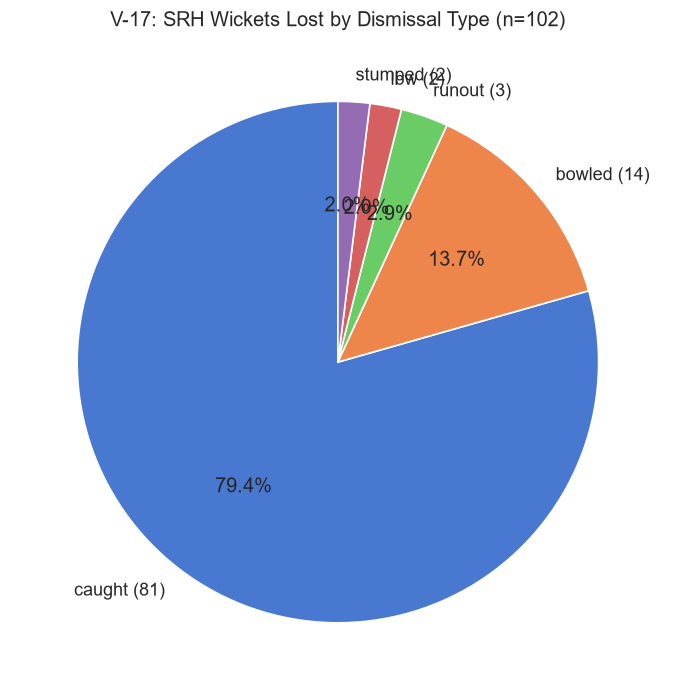

C:\Users\lanka\AppData\Local\Temp\ipykernel_1008\3666869469.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(bowl18['bowler'], rotation=35, ha='right', fontsize=9)


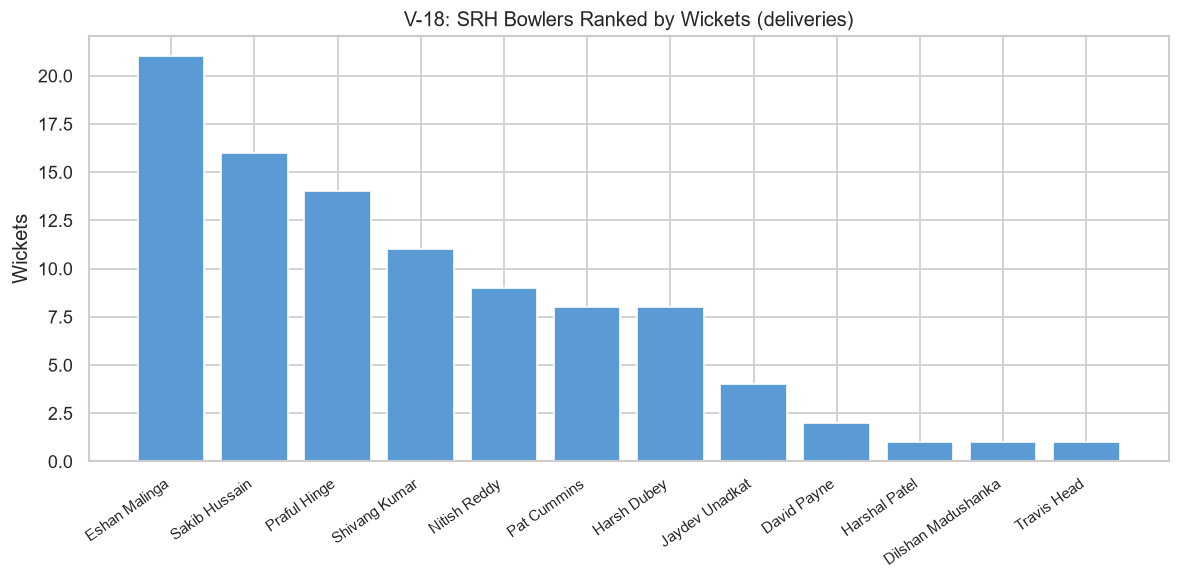

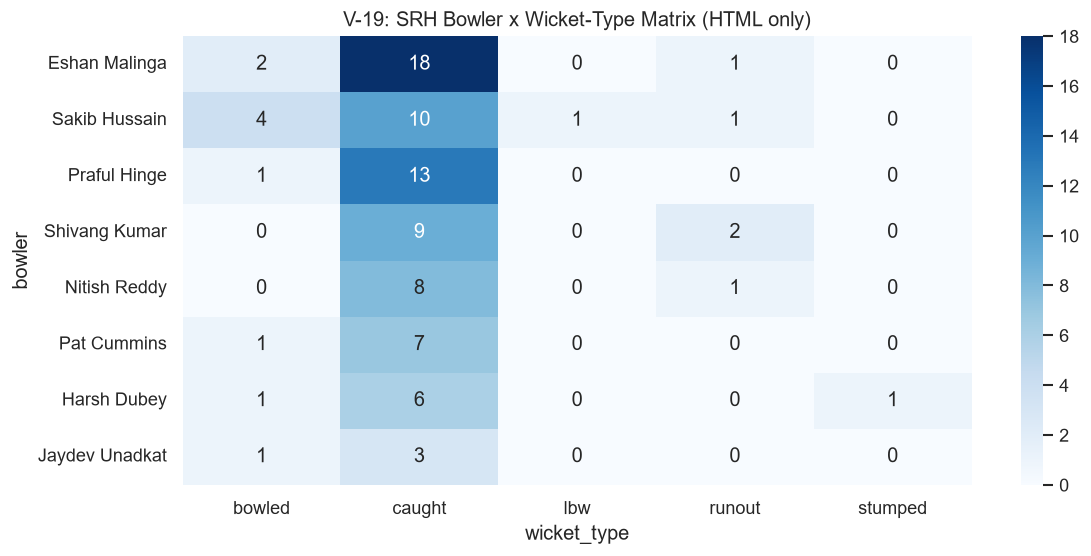

In [132]:
# V-16: SRH Wickets Taken by Dismissal Type
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(wkt_taken_vc['count'],
       labels=[f"{r} ({c})" for r,c in zip(wkt_taken_vc['wicket_type'],wkt_taken_vc['count'])],
       autopct='%1.1f%%', startangle=90)
ax.set_title(f'V-16: SRH Wickets Taken by Dismissal Type (n={len(srh_wkts_taken)})')
plt.tight_layout()
plt.savefig(VISUALS / 'V-16_srh_wickets_taken_type.png', dpi=150, bbox_inches='tight')
plt.show()

# V-17: SRH Wickets Lost by Dismissal Type
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(wkt_lost_vc['count'],
       labels=[f"{r} ({c})" for r,c in zip(wkt_lost_vc['wicket_type'],wkt_lost_vc['count'])],
       autopct='%1.1f%%', startangle=90)
ax.set_title(f'V-17: SRH Wickets Lost by Dismissal Type (n={len(srh_wkts_lost)})')
plt.tight_layout()
plt.savefig(VISUALS / 'V-17_srh_wickets_lost_type.png', dpi=150, bbox_inches='tight')
plt.show()

# V-18: SRH Bowlers Ranked by Wickets (from deliveries)
bowl18 = bowl_stats.sort_values('wickets', ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bowl18['bowler'], bowl18['wickets'], color='#5B9BD5')
ax.set_ylabel('Wickets')
ax.set_title('V-18: SRH Bowlers Ranked by Wickets (deliveries)')
ax.set_xticklabels(bowl18['bowler'], rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(VISUALS / 'V-18_srh_bowlers_ranked.png', dpi=150, bbox_inches='tight')
plt.show()

# V-19: Bowler x wicket-type heatmap (HTML only)
bw_heat = bowler_wkt.drop(columns='total')
bw_heat = bw_heat[bw_heat.sum(axis=1)>=3]   # bowlers with >=3 wickets
if len(bw_heat) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(bw_heat)*0.6)))
    sns.heatmap(bw_heat, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title('V-19: SRH Bowler x Wicket-Type Matrix (HTML only)')
    plt.tight_layout()
    plt.savefig(VISUALS / 'V-19_bowler_wicket_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Section 10: Venue Analysis

SRH performance at each venue. Home vs. away split. Sample sizes stated for every metric.

In [133]:
# 11a. SRH matches per venue
srh_venue_matches = (df_srh_all_del.groupby('venue_clean')['match_no']
                     .nunique().sort_values(ascending=False).reset_index(name='matches'))
print('SRH matches per venue:')
display(srh_venue_matches)

# 11b. SRH batting per venue
def venue_bat(df):
    g = df.groupby('venue_clean')
    r = pd.DataFrame({
        'legal_del': g.apply(lambda x: x['is_legal_delivery'].sum()),
        'runs':      g['runs_of_bat'].sum(),
        'fours':     g.apply(lambda x: (x['runs_of_bat']==4).sum()),
        'sixes':     g.apply(lambda x: (x['runs_of_bat']==6).sum()),
    }).reset_index()
    r['run_rate']    = (r['runs']/(r['legal_del']/6)).round(2)
    r['boundary_pct']= ((r['fours']+r['sixes'])/r['legal_del']*100).round(1)
    return r.sort_values('run_rate', ascending=False)

srh_venue_bat = venue_bat(df_srh_bat_del)
print('SRH batting by venue:')
display(srh_venue_bat)

# 11c. SRH bowling per venue
def venue_bowl(df):
    g = df.groupby('venue_clean')
    r = pd.DataFrame({
        'legal_del': g.apply(lambda x: x['is_legal_delivery'].sum()),
        'runs_con':  g.apply(lambda x: x['runs_of_bat'].sum()+(x['wide']+x['noballs']).sum()),
        'wickets':   g['wicket_type'].apply(lambda s: s.notna().sum()),
    }).reset_index()
    r['economy'] = (r['runs_con']/(r['legal_del']/6)).round(2)
    return r.sort_values('economy')

srh_venue_bowl = venue_bowl(df_srh_bowl_del)
print('SRH bowling by venue:')
display(srh_venue_bowl)

# 11d. Home vs. away split
df_srh_bat_del['is_home'] = df_srh_bat_del['venue_clean'] == srh_home_venue
for home_val, label in [(True,'Home'),(False,'Away')]:
    sub = df_srh_bat_del[df_srh_bat_del['is_home']==home_val]
    leg = sub['is_legal_delivery'].sum()
    rns = sub['runs_of_bat'].sum()
    rr  = rns/(leg/6) if leg>0 else 0
    print(f'  {label}: {len(sub["match_no"].unique())} matches | {leg} legal del | run rate {rr:.2f}')

# 11e. Venue metadata join
venue_meta = (srh_venue_bat.merge(
    df_venues[['venue_stadium','city','state','capacity']],
    left_on='venue_clean', right_on='venue_stadium', how='left')
    .drop(columns='venue_stadium'))
print('\nVenue batting with metadata (capacity = descriptive context only):')
display(venue_meta[['venue_clean','matches_played' if 'matches_played' in venue_meta.columns
                     else 'venue_clean','legal_del','run_rate','city','state','capacity']])

SRH matches per venue:


,venue_clean,matches
0,Rajiv Gandhi International Stadium,7
1,New PCA Cricket Stadium,2
2,Eden Gardens,1
3,M. Chinnaswamy Stadium,1
4,Narendra Modi Stadium,1
5,MA Chidambaram Stadium,1
6,Sawai Mansingh Stadium,1
7,Wankhede Stadium,1


SRH batting by venue:


,venue_clean,legal_del,runs,fours,sixes,run_rate,boundary_pct
7,Wankhede Stadium,112,237,20,18,12.70,33.9
6,Sawai Mansingh Stadium,111,211,27,10,11.41,33.3
0,Eden Gardens,120,213,24,9,10.65,27.5
5,Rajiv Gandhi International Stadium,834,1400,111,89,10.07,24.0
4,New PCA Cricket Stadium,236,386,31,22,9.81,22.5
1,M. Chinnaswamy Stadium,121,196,15,12,9.72,22.3
2,MA Chidambaram Stadium,114,176,19,7,9.26,22.8
3,Narendra Modi Stadium,89,84,8,4,5.66,13.5


SRH bowling by venue:


,venue_clean,legal_del,runs_con,wickets,economy
3,Narendra Modi Stadium,120,164,5,8.20
2,MA Chidambaram Stadium,120,179,7,8.95
5,Rajiv Gandhi International Stadium,824,1247,46,9.08
0,Eden Gardens,96,158,10,9.88
6,Sawai Mansingh Stadium,119,226,6,11.39
4,New PCA Cricket Stadium,233,464,12,11.95
7,Wankhede Stadium,120,242,5,12.10
1,M. Chinnaswamy Stadium,95,192,5,12.13


  Home: 7 matches | 834 legal del | run rate 10.07
  Away: 8 matches | 903 legal del | run rate 9.99

Venue batting with metadata (capacity = descriptive context only):


,venue_clean,venue_clean,legal_del,run_rate,city,state,capacity
0,Wankhede Stadium,Wankhede Stadium,112,12.70,Mumbai,Maharashtra,33108
1,Sawai Mansingh Stadium,Sawai Mansingh Stadium,111,11.41,Jaipur,Rajasthan,30000
2,Eden Gardens,Eden Gardens,120,10.65,Kolkata,West Bengal,68000
3,Rajiv Gandhi International Stadium,Rajiv Gandhi International Stadium,834,10.07,Hyderabad,Telangana,55000
4,New PCA Cricket Stadium,New PCA Cricket Stadium,236,9.81,Chandigarh,Punjab,38000
5,M. Chinnaswamy Stadium,M. Chinnaswamy Stadium,121,9.72,Bengaluru,Karnataka,33800
6,MA Chidambaram Stadium,MA Chidambaram Stadium,114,9.26,Chennai,Tamil Nadu,50000
7,Narendra Modi Stadium,Narendra Modi Stadium,89,5.66,Ahmedabad,Gujrat,132000


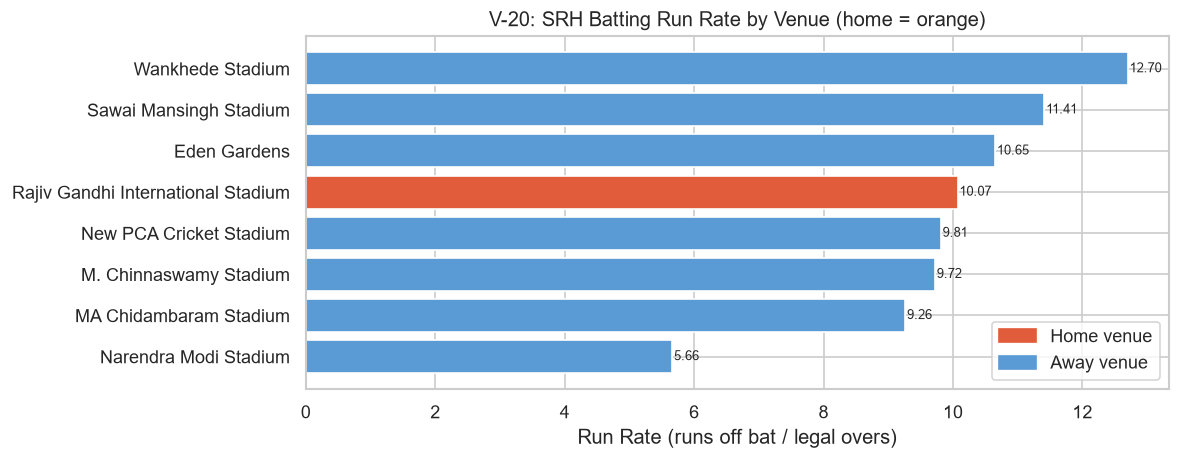

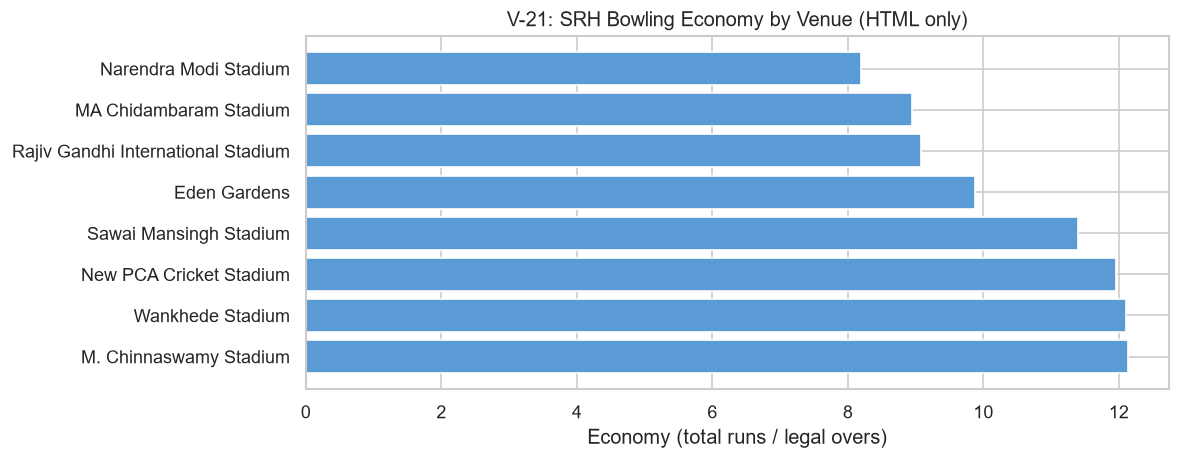

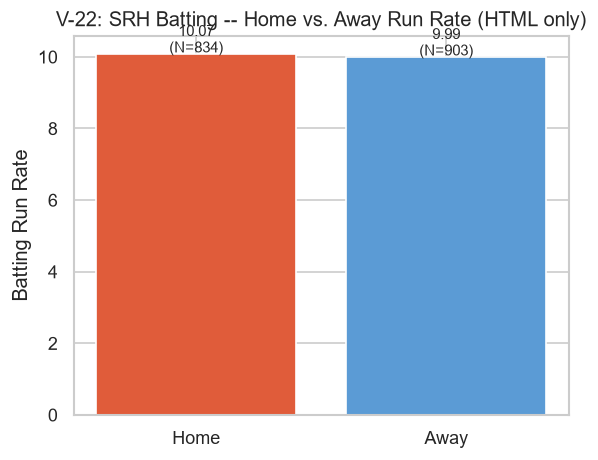

In [134]:
# V-20: SRH Batting Run Rate by Venue
vb = srh_venue_bat.sort_values('run_rate', ascending=True)
colors20 = ['#E05C3A' if v==srh_home_venue else '#5B9BD5' for v in vb['venue_clean']]
fig, ax = plt.subplots(figsize=(10, max(4, len(vb)*0.5)))
ax.barh(vb['venue_clean'], vb['run_rate'], color=colors20)
ax.set_xlabel('Run Rate (runs off bat / legal overs)')
ax.set_title('V-20: SRH Batting Run Rate by Venue (home = orange)')
home_p = mpatches.Patch(color='#E05C3A', label='Home venue')
away_p = mpatches.Patch(color='#5B9BD5', label='Away venue')
ax.legend(handles=[home_p, away_p])
for bar, val in zip(ax.patches, vb['run_rate']):
    ax.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(VISUALS / 'V-20_venue_batting_rr.png', dpi=150, bbox_inches='tight')
plt.show()

# V-21: SRH Bowling Economy by Venue (HTML only)
vbw = srh_venue_bowl.sort_values('economy', ascending=False)
fig, ax = plt.subplots(figsize=(10, max(4, len(vbw)*0.5)))
ax.barh(vbw['venue_clean'], vbw['economy'], color='#5B9BD5')
ax.set_xlabel('Economy (total runs / legal overs)')
ax.set_title('V-21: SRH Bowling Economy by Venue (HTML only)')
plt.tight_layout()
plt.savefig(VISUALS / 'V-21_venue_bowling_economy.png', dpi=150, bbox_inches='tight')
plt.show()

# V-22: Home vs. Away comparison (HTML only)
ha_data = []
for home_val, label in [(True,'Home'),(False,'Away')]:
    sub = df_srh_bat_del[df_srh_bat_del['is_home']==home_val]
    leg = sub['is_legal_delivery'].sum()
    rns = sub['runs_of_bat'].sum()
    ha_data.append({'Split':label,'run_rate': rns/(leg/6) if leg>0 else 0,'legal_del':leg})
ha_df = pd.DataFrame(ha_data)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(ha_df['Split'], ha_df['run_rate'], color=['#E05C3A','#5B9BD5'])
ax.set_ylabel('Batting Run Rate')
ax.set_title('V-22: SRH Batting -- Home vs. Away Run Rate (HTML only)')
for i, row in ha_df.iterrows():
    ax.text(i, row['run_rate']+0.05, f"{row['run_rate']:.2f}\n(N={row['legal_del']})",
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(VISUALS / 'V-22_home_vs_away.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 11: League Stage vs. Playoffs Analysis

> **Caveat:** The League stage dataset contains substantially more deliveries than Playoffs and Final
> combined. All stage comparisons are directional observations and are not statistically conclusive findings.

In [135]:
# Stage values
print('stage values in dataset:', df_del['stage'].unique().tolist())
stage_cnt = df_srh_all_del.groupby('stage').agg(
    matches=('match_no','nunique'),
    deliveries=('match_no','count')
).reset_index()
print('SRH deliveries per stage:')
display(stage_cnt)

# SRH batting per stage
def stage_bat(df):
    g = df.groupby('stage')
    r = pd.DataFrame({
        'legal_del': g.apply(lambda x: x['is_legal_delivery'].sum()),
        'runs':      g['runs_of_bat'].sum(),
        'wickets':   g['wicket_type'].apply(lambda s: s.notna().sum()),
        'fours':     g.apply(lambda x: (x['runs_of_bat']==4).sum()),
        'sixes':     g.apply(lambda x: (x['runs_of_bat']==6).sum()),
    }).reset_index()
    r['run_rate']    = (r['runs']/(r['legal_del']/6)).round(2)
    r['boundary_pct']= ((r['fours']+r['sixes'])/r['legal_del']*100).round(1)
    return r

srh_stage_bat  = stage_bat(df_srh_bat_del)
print('SRH batting by stage (legal_del = N):')
display(srh_stage_bat)

def stage_bowl(df):
    g = df.groupby('stage')
    r = pd.DataFrame({
        'legal_del': g.apply(lambda x: x['is_legal_delivery'].sum()),
        'runs_con':  g.apply(lambda x: x['runs_of_bat'].sum()+(x['wide']+x['noballs']).sum()),
        'wickets':   g['wicket_type'].apply(lambda s: s.notna().sum()),
    }).reset_index()
    r['economy'] = (r['runs_con']/(r['legal_del']/6)).round(2)
    return r

srh_stage_bowl = stage_bowl(df_srh_bowl_del)
print('SRH bowling by stage:')
display(srh_stage_bowl)

# Phase x Stage pivot
piv = (df_srh_bat_del.groupby(['stage','phase'])
       .apply(lambda x: x['is_legal_delivery'].sum())
       .unstack(fill_value=0))
print('\nPhase x Stage pivot (SRH batting legal deliveries):')
display(piv)

stage values in dataset: ['League stage', 'Playoffs', 'Final']
SRH deliveries per stage:


,stage,matches,deliveries
0,League stage,14,3399
1,Playoffs,1,252


SRH batting by stage (legal_del = N):


,stage,legal_del,runs,wickets,fours,sixes,run_rate,boundary_pct
0,League stage,1621,2723,92,239,162,10.08,24.7
1,Playoffs,116,180,10,16,9,9.31,21.6


SRH bowling by stage:


,stage,legal_del,runs_con,wickets,economy
0,League stage,1607,2631,88,9.82
1,Playoffs,120,241,8,12.05



Phase x Stage pivot (SRH batting legal deliveries):


phase,Death,Middle,Powerplay
stage,,,
League stage,283,834,504
Playoffs,20,60,36


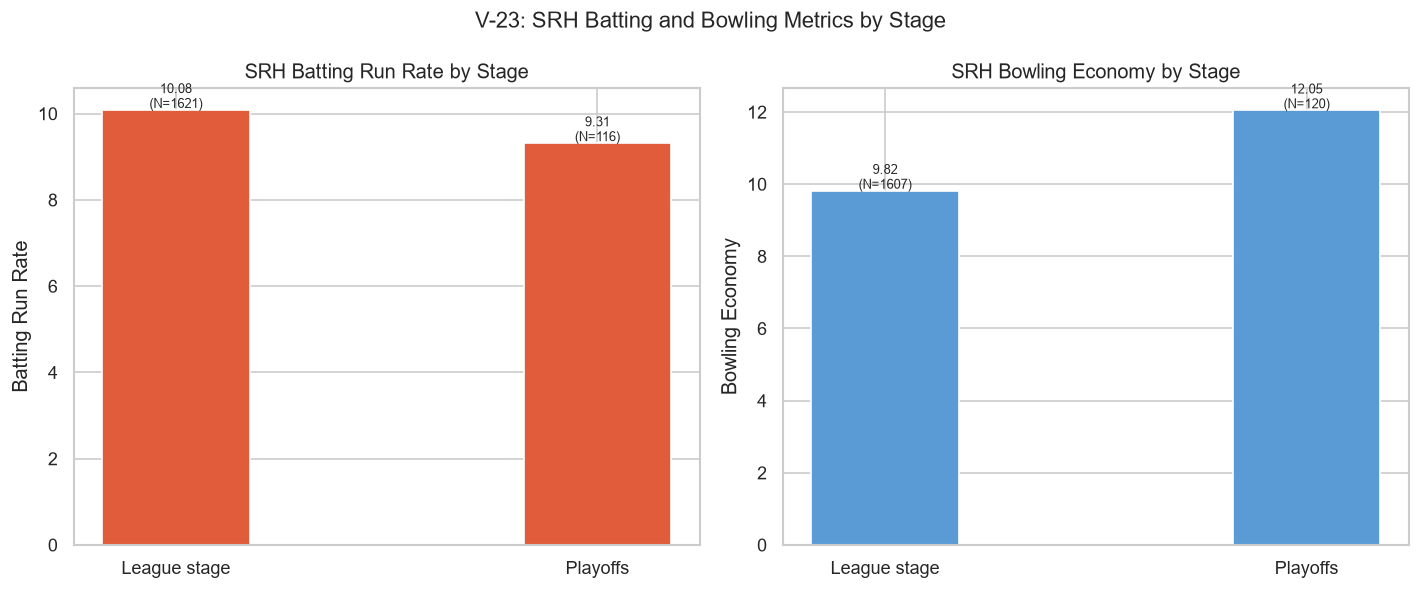

In [136]:
# V-23: SRH Batting and Bowling Metrics by Stage
stages = srh_stage_bat['stage'].tolist()
x23 = np.arange(len(stages)); w23 = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Batting run rate
axes[0].bar(x23, srh_stage_bat['run_rate'], w23, color='#E05C3A')
axes[0].set_xticks(x23); axes[0].set_xticklabels(stages)
axes[0].set_ylabel('Batting Run Rate')
axes[0].set_title('SRH Batting Run Rate by Stage')
for i, v in enumerate(srh_stage_bat['run_rate']):
    n = srh_stage_bat.iloc[i]['legal_del']
    axes[0].text(i, v+0.05, f'{v:.2f}\n(N={n})', ha='center', fontsize=8)

# Bowling economy
axes[1].bar(x23, srh_stage_bowl['economy'], w23, color='#5B9BD5')
axes[1].set_xticks(x23); axes[1].set_xticklabels(stages)
axes[1].set_ylabel('Bowling Economy')
axes[1].set_title('SRH Bowling Economy by Stage')
for i, v in enumerate(srh_stage_bowl['economy']):
    n = srh_stage_bowl.iloc[i]['legal_del']
    axes[1].text(i, v+0.05, f'{v:.2f}\n(N={n})', ha='center', fontsize=8)

fig.suptitle('V-23: SRH Batting and Bowling Metrics by Stage', fontsize=13)
plt.tight_layout()
plt.savefig(VISUALS / 'V-23_metrics_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 12: Player Performance Analysis

> Players with delivery records in both the SRH batting and SRH bowling subsets are identified
> as contributing in both batting and bowling. No `role` field exists in any dataset; this is a
> data-presence observation only.

In [137]:
# 13a. Dual-contribution player identification
bat_players  = set(df_srh_bat_del['striker'].unique())
bowl_players = set(df_srh_bowl_del['bowler'].unique())
dual_players = sorted(bat_players.intersection(bowl_players))

print(f'Players with records in both SRH batting and SRH bowling subsets (n={len(dual_players)}):')
print(dual_players)
print('Note: no role field exists in any dataset; data-presence observation only.')

# Combined stats for dual-contribution players
dual_rows = []
for player in dual_players:
    bat_sub  = df_srh_bat_del[df_srh_bat_del['striker'] == player]
    bowl_sub = df_srh_bowl_del[df_srh_bowl_del['bowler'] == player]
    b_legal  = bat_sub['is_legal_delivery'].sum()
    b_runs   = bat_sub['runs_of_bat'].sum()
    b_sr     = round(b_runs/b_legal*100, 1) if b_legal>0 else 0
    bw_legal = bowl_sub['is_legal_delivery'].sum()
    bw_runs  = (bowl_sub['runs_of_bat'].sum()+
                (bowl_sub['wide']+bowl_sub['noballs']).sum())
    bw_wkts  = bowl_sub['wicket_type'].notna().sum()
    bw_econ  = round(bw_runs/(bw_legal/6), 2) if bw_legal>0 else 0
    dual_rows.append({'player':player,
                      'bat_legal':b_legal,'bat_runs':b_runs,'bat_sr':b_sr,
                      'bowl_legal':bw_legal,'bowl_wickets':bw_wkts,'bowl_economy':bw_econ})

dual_df = pd.DataFrame(dual_rows)
display(dual_df)

Players with records in both SRH batting and SRH bowling subsets (n=12):
['Abhishek Sharma', 'David Payne', 'Eshan Malinga', 'Harsh Dubey', 'Harshal Patel', 'Jaydev Unadkat', 'Nitish Reddy', 'Pat Cummins', 'Praful Hinge', 'Sakib Hussain', 'Shivang Kumar', 'Travis Head']
Note: no role field exists in any dataset; data-presence observation only.


,player,bat_legal,bat_runs,bat_sr,bowl_legal,bowl_wickets,bowl_economy
0,Abhishek Sharma,275,563,204.7,29,0,10.14
1,David Payne,5,6,120.0,30,2,14.00
2,Eshan Malinga,17,7,41.2,326,21,9.29
3,Harsh Dubey,9,13,144.4,132,8,10.27
4,Harshal Patel,9,10,111.1,84,1,10.57
5,Jaydev Unadkat,3,4,133.3,77,4,10.91
6,Nitish Reddy,176,302,171.6,186,9,10.42
7,Pat Cummins,19,30,157.9,192,8,9.41
8,Praful Hinge,9,3,33.3,156,14,11.65
9,Sakib Hussain,7,5,71.4,252,16,9.33


In [138]:
# 13b. Batting profiles >= 20 legal balls
bat20 = bat_stats[bat_stats['legal_balls']>=20].sort_values('runs', ascending=False)
print(f'SRH batsmen with >=20 legal balls (n={len(bat20)}):')
display(bat20)

# Cross-reference with batting_stats.csv for top-3
bat_merged = bat20.merge(df_srh_bat_stats[['batsman','matches','average','strike_rate','impact']],
                          left_on='striker', right_on='batsman', how='inner')
if len(bat_merged)>0:
    print('\nDelivery-derived stats alongside batting_stats.csv for SRH top-3:')
    display(bat_merged)

SRH batsmen with >=20 legal balls (n=10):


,striker,legal_balls,runs,fours,sixes,dots,strike_rate,dot_pct
0,Heinrich Klaasen,390,624,48,31,105,160.00,26.9
1,Ishan Kishan,331,604,60,32,87,182.48,26.3
2,Abhishek Sharma,275,563,50,43,89,204.73,32.4
3,Travis Head,240,410,46,23,96,170.83,40.0
4,Nitish Reddy,176,302,19,21,48,171.59,27.3
5,Salil Arora,98,156,11,11,34,159.18,34.7
6,Aniket Verma,54,79,6,5,20,146.30,37.0
7,Shivang Kumar,45,53,6,1,19,117.78,42.2
9,Smaran Ravichandran,25,19,3,0,15,76.00,60.0
10,Liam Livingstone,25,15,0,1,17,60.00,68.0



Delivery-derived stats alongside batting_stats.csv for SRH top-3:


,striker,legal_balls,runs,fours,sixes,dots,strike_rate_x,dot_pct,batsman,matches,average,strike_rate_y,impact
0,Heinrich Klaasen,390,624,48,31,105,160.00,26.9,Heinrich Klaasen,8,49.85,149.78,258.6
1,Ishan Kishan,331,604,60,32,87,182.48,26.3,Ishan Kishan,8,39.00,198.72,381.7
2,Abhishek Sharma,275,563,50,43,89,204.73,32.4,Abhishek Sharma,8,54.28,212.29,395.6


In [139]:
# 13c. Bowling profiles >= 12 legal deliveries
bowl12 = bowl_stats[bowl_stats['legal_del']>=12].sort_values('wickets', ascending=False)
print(f'SRH bowlers with >=12 legal deliveries (n={len(bowl12)}):')
display(bowl12)

# Cross-reference with bowling.csv (Best Figures excluded)
BOWL_COLS_SAFE = [c for c in df_bowl.columns if c != 'Best Figures']
bowl_merged = bowl12.merge(df_srh_bowl_stats[BOWL_COLS_SAFE],
                            left_on='bowler', right_on='Player', how='inner')
if len(bowl_merged)>0:
    print('\nDelivery-derived stats alongside bowling.csv (Best Figures excluded) for SRH top-2:')
    display(bowl_merged)

SRH bowlers with >=12 legal deliveries (n=12):


,bowler,legal_del,runs_con,wickets,wides,noballs,dots,overs,economy,dot_pct,extras_po
0,Eshan Malinga,326,505,21,23,0,117,54.33,9.29,35.9,0.42
1,Sakib Hussain,252,392,16,20,1,87,42.00,9.33,34.5,0.50
2,Praful Hinge,156,303,14,7,3,62,26.00,11.65,39.7,0.38
3,Shivang Kumar,233,373,11,5,0,63,38.83,9.61,27.0,0.13
4,Nitish Reddy,186,323,9,10,1,57,31.00,10.42,30.6,0.35
5,Pat Cummins,192,301,8,7,2,70,32.00,9.41,36.5,0.28
6,Harsh Dubey,132,226,8,6,0,38,22.00,10.27,28.8,0.27
7,Jaydev Unadkat,77,140,4,1,0,23,12.83,10.91,29.9,0.08
8,David Payne,30,70,2,1,0,5,5.00,14.00,16.7,0.20
9,Harshal Patel,84,148,1,2,0,18,14.00,10.57,21.4,0.14



Delivery-derived stats alongside bowling.csv (Best Figures excluded) for SRH top-2:


,bowler,legal_del,runs_con,wickets,wides,noballs,dots,overs,economy,dot_pct,...,Rank,Player,Team,Matches,Overs,Runs,Wickets,Average,Economy,team
0,Eshan Malinga,326,505,21,23,0,117,54.33,9.29,35.9,...,6,Eshan Malinga,Sunrisers Hyderabad,15,54.2,507,20,25.35,9.33,SRH
1,Sakib Hussain,252,392,16,20,1,87,42.00,9.33,34.5,...,14,Sakib Hussain,Sunrisers Hyderabad,11,42.0,397,15,26.47,9.45,SRH


In [140]:
# 13d. Fielding profiles
print('SRH fielding stats (from fielding_stats.csv, top-15 catch leaders only):')
display(df_srh_field_stats)
print('Rank within top-15 catch leaders:')
for _, row in df_srh_field_stats.iterrows():
    print(f"  {row['player']}: Rank {row['rank']} of 15 (catches={row['catches']}, cpm={row['cpm']})")

SRH fielding stats (from fielding_stats.csv, top-15 catch leaders only):


,rank,player,team,matches,catches,cpm
6,7,Heinrich Klaasen,SRH,8,7,0.875
7,8,Nitish Kumar Reddy,SRH,8,7,0.875


Rank within top-15 catch leaders:
  Heinrich Klaasen: Rank 7 of 15 (catches=7, cpm=0.875)
  Nitish Kumar Reddy: Rank 8 of 15 (catches=7, cpm=0.875)


In [141]:
# 13e. Squad summary table
all_srh_bat  = bat_stats[['striker','runs','strike_rate']].rename(columns={'striker':'player','runs':'bat_runs','strike_rate':'bat_sr'})
all_srh_bowl = bowl_stats[['bowler','wickets','economy']].rename(columns={'bowler':'player','wickets':'bowl_wickets','economy':'bowl_economy'})
all_srh_field= df_srh_field_stats[['player','catches']].copy()

squad = (all_srh_bat
         .merge(all_srh_bowl,  on='player', how='outer')
         .merge(all_srh_field, on='player', how='outer'))
squad = squad.sort_values('bat_runs', ascending=False).reset_index(drop=True)
squad['data_sources'] = squad.apply(lambda r:
    ','.join(filter(None,[
        'deliveries(bat)' if pd.notna(r['bat_runs']) else '',
        'deliveries(bowl)' if pd.notna(r['bowl_wickets']) else '',
        'fielding_stats' if pd.notna(r['catches']) else ''
    ])), axis=1)
print(f'SRH squad summary (all players across all 5 datasets, n={len(squad)}):')
display(squad)

SRH squad summary (all players across all 5 datasets, n=20):


,player,bat_runs,bat_sr,bowl_wickets,bowl_economy,catches,data_sources
0,Heinrich Klaasen,624.0,160.00,NaN,NaN,7.0,"deliveries(bat),fielding_stats"
1,Ishan Kishan,604.0,182.48,NaN,NaN,NaN,deliveries(bat)
2,Abhishek Sharma,563.0,204.73,0.0,10.14,NaN,"deliveries(bat),deliveries(bowl)"
3,Travis Head,410.0,170.83,1.0,7.00,NaN,"deliveries(bat),deliveries(bowl)"
4,Nitish Reddy,302.0,171.59,9.0,10.42,NaN,"deliveries(bat),deliveries(bowl)"
5,Salil Arora,156.0,159.18,NaN,NaN,NaN,deliveries(bat)
6,Aniket Verma,79.0,146.30,NaN,NaN,NaN,deliveries(bat)
7,Shivang Kumar,53.0,117.78,11.0,9.61,NaN,"deliveries(bat),deliveries(bowl)"
8,Pat Cummins,30.0,157.89,8.0,9.41,NaN,"deliveries(bat),deliveries(bowl)"
9,Smaran Ravichandran,19.0,76.00,NaN,NaN,NaN,deliveries(bat)


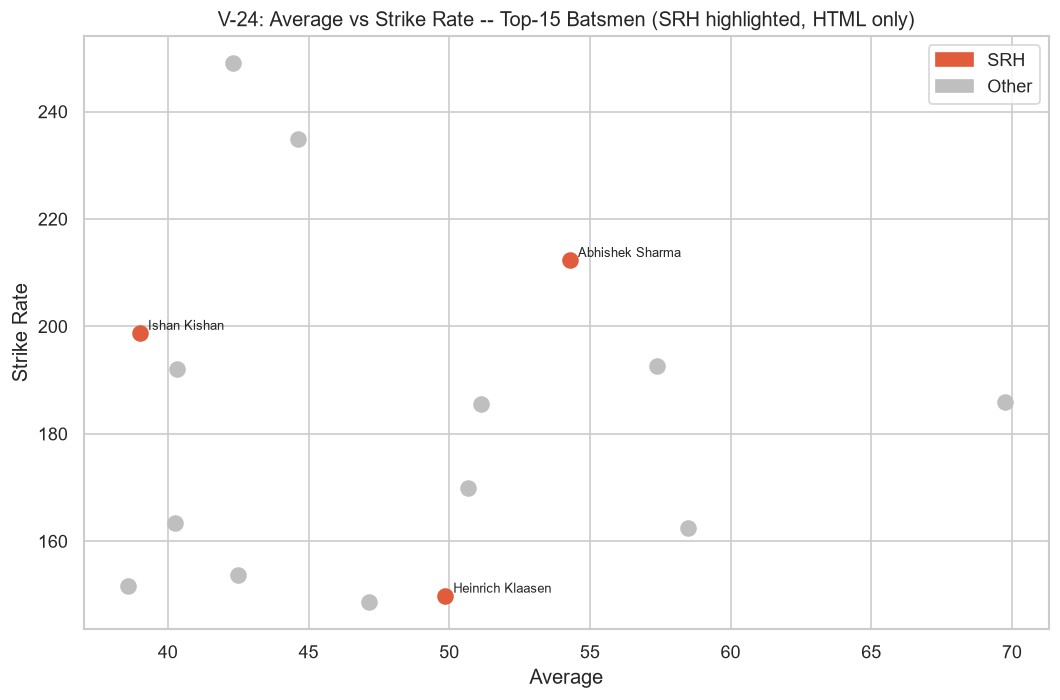

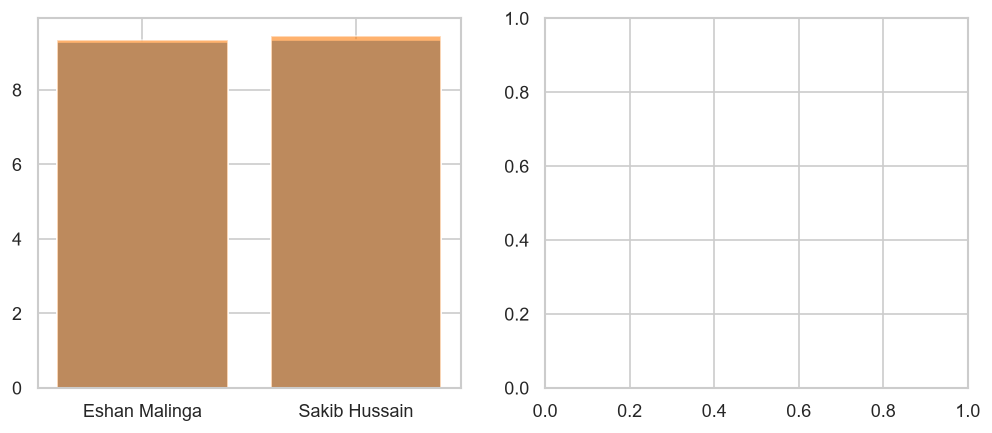

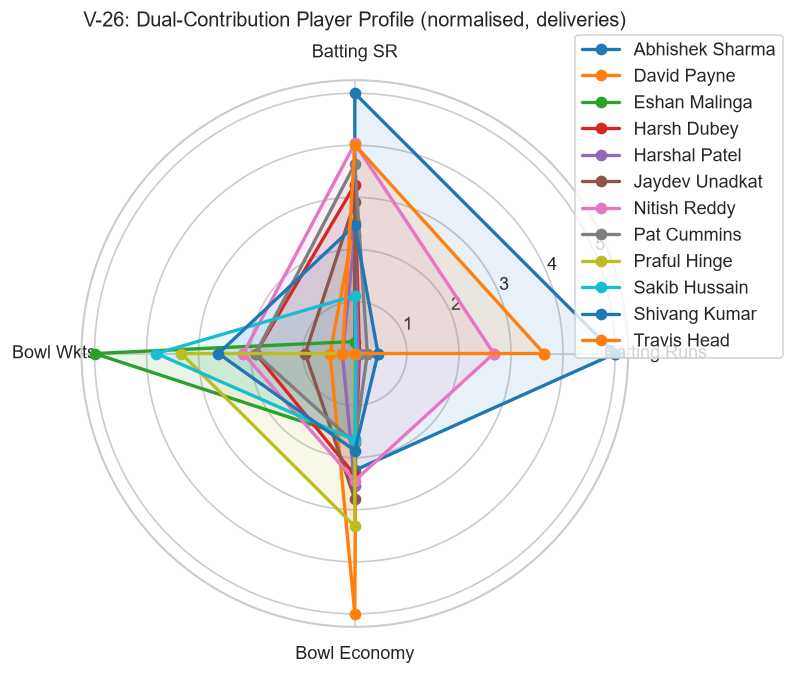

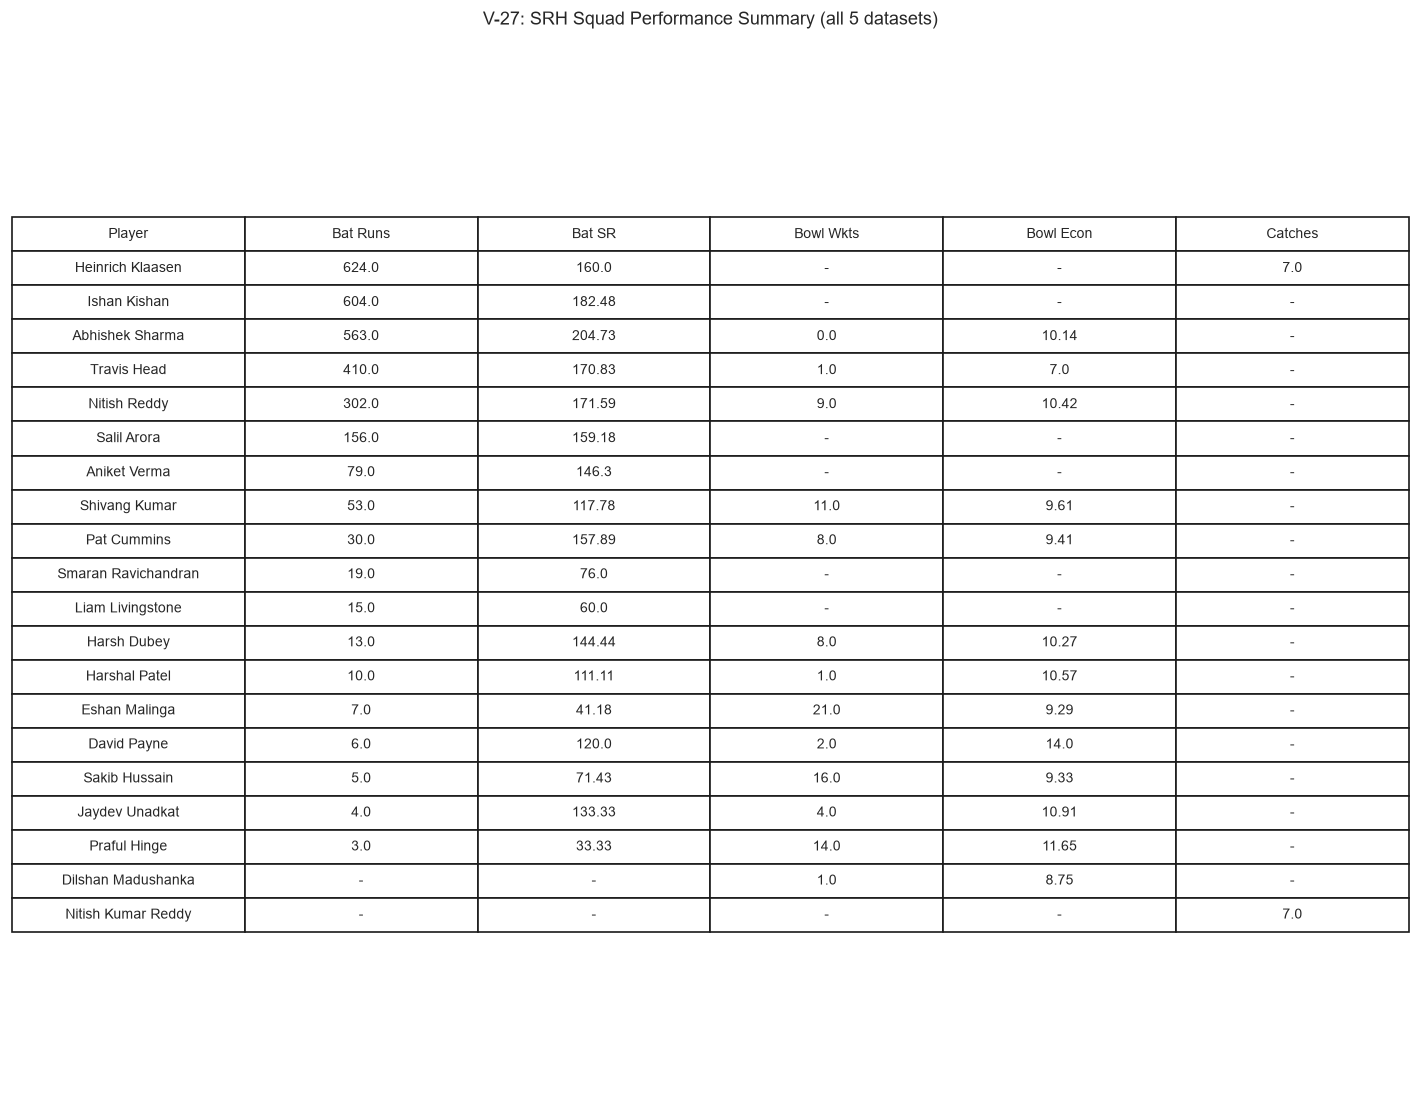

In [142]:
# V-24: Avg vs SR scatter for top-15 batsmen, SRH highlighted (HTML only)
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df_bat.iterrows():
    clr = '#E05C3A' if row['team']=='SRH' else '#BFBFBF'
    ax.scatter(row['average'], row['strike_rate'], color=clr, s=80, zorder=3)
    if row['team']=='SRH':
        ax.annotate(row['batsman'], (row['average'], row['strike_rate']),
                    textcoords='offset points', xytext=(5,2), fontsize=8)
ax.set_xlabel('Average'); ax.set_ylabel('Strike Rate')
ax.set_title('V-24: Average vs Strike Rate -- Top-15 Batsmen (SRH highlighted, HTML only)')
srh_p = mpatches.Patch(color='#E05C3A', label='SRH')
oth_p = mpatches.Patch(color='#BFBFBF', label='Other')
ax.legend(handles=[srh_p, oth_p])
plt.tight_layout()
plt.savefig(VISUALS / 'V-24_avg_vs_sr_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# V-25: Bowler combined comparison (HTML only)
# V-25: Bowler combined comparison (HTML only)
if len(bowl_merged) > 0:
    fig, axes = plt.subplots(1,2,figsize=(10,4))
    axes[0].bar(bowl_merged['bowler'], bowl_merged['economy'],
                color='#5B9BD5', label='Deliveries-derived')
    axes[0].bar(bowl_merged['bowler'], bowl_merged['Economy'],
                alpha=0.6, color='#FF7F0E', label='bowling.csv')
# V-26: Dual-contribution radar
if len(dual_df) > 0:
    categories = ['bat_runs','bat_sr','bowl_wickets','bowl_economy']
    norm_df    = dual_df[categories].copy()
    for col in categories:
        rng = norm_df[col].max() - norm_df[col].min()
        norm_df[col] = ((norm_df[col] - norm_df[col].min()) / rng * 5).fillna(0) if rng>0 else 0
    N      = len(categories)
    angles = [n/float(N)*2*np.pi for n in range(N)]
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw={'polar':True})
    colors_radar = plt.cm.tab10.colors
    for i, (_, row) in enumerate(norm_df.iterrows()):
        vals = row[categories].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', lw=2, color=colors_radar[i%10],
                label=dual_df.iloc[i]['player'])
        ax.fill(angles, vals, alpha=0.1, color=colors_radar[i%10])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Batting Runs','Batting SR','Bowl Wkts','Bowl Economy'])
    ax.set_title('V-26: Dual-Contribution Player Profile (normalised, deliveries)', y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
    plt.tight_layout()
    plt.savefig(VISUALS / 'V-26_dual_contribution_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

# V-27: Squad summary table as figure
squad_display = squad[['player','bat_runs','bat_sr','bowl_wickets','bowl_economy','catches']].fillna('-')
fig, ax = plt.subplots(figsize=(12, max(4, len(squad_display)*0.4+1.5)))
ax.axis('off')
col_labels = ['Player','Bat Runs','Bat SR','Bowl Wkts','Bowl Econ','Catches']
tbl = ax.table(cellText=squad_display.values, colLabels=col_labels,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)
ax.set_title('V-27: SRH Squad Performance Summary (all 5 datasets)', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(VISUALS / 'V-27_squad_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 13: Cross-Dataset Integration

Four explicit joins across all five datasets.

| Dataset | Key Join Column | Connects To |
|---|---|---|
| deliveries | `batting_team` / `bowling_team` | All SRH team-level filters |
| deliveries | `striker` | `batting_stats.batsman` |
| deliveries | `bowler` | `bowling.Player` (after TEAM_MAP) |
| deliveries | `fielder` | `fielding_stats.player` |
| deliveries | `venue_clean` | `venues.venue_stadium` |

In [143]:
# Integration 1: Player batting enrichment
del_bat_per_player = bat_stats[bat_stats['legal_balls']>=1][['striker','legal_balls','runs','strike_rate']]
int1 = del_bat_per_player.merge(df_srh_bat_stats[['batsman','matches','average','strike_rate','impact']],
                                 left_on='striker', right_on='batsman', how='inner',
                                 suffixes=('_del','_csv'))
print('Integration 1: Delivery-level batting + batting_stats.csv (join: striker == batsman)')
display(int1)

# Integration 2: Venue enrichment
int2 = (srh_venue_bat.merge(df_venues[['venue_stadium','city','state','capacity']],
                              left_on='venue_clean', right_on='venue_stadium', how='left')
        .drop(columns='venue_stadium'))
print('\nIntegration 2: SRH venue batting + venues.csv (join: venue_clean == venue_stadium)')
display(int2[['venue_clean','legal_del','run_rate','city','state','capacity']])

# Integration 3: Bowling enrichment (Best Figures excluded)
BCOLS = [c for c in df_bowl.columns if c != 'Best Figures']
int3 = bowl12.merge(df_srh_bowl_stats[BCOLS], left_on='bowler', right_on='Player', how='inner')
print('\nIntegration 3: Delivery bowler stats + bowling.csv (Best Figures excluded, join: bowler == Player)')
display(int3)

# Integration 4: Fielding enrichment
int4 = df_srh_field_stats.merge(fielder_inv, left_on='player', right_on='fielder', how='left')
print('\nIntegration 4: fielding_stats.csv + fielder involvement from deliveries')
display(int4)

Integration 1: Delivery-level batting + batting_stats.csv (join: striker == batsman)


,striker,legal_balls,runs,strike_rate_del,batsman,matches,average,strike_rate_csv,impact
0,Heinrich Klaasen,390,624,160.00,Heinrich Klaasen,8,49.85,149.78,258.6
1,Ishan Kishan,331,604,182.48,Ishan Kishan,8,39.00,198.72,381.7
2,Abhishek Sharma,275,563,204.73,Abhishek Sharma,8,54.28,212.29,395.6



Integration 2: SRH venue batting + venues.csv (join: venue_clean == venue_stadium)


,venue_clean,legal_del,run_rate,city,state,capacity
0,Wankhede Stadium,112,12.70,Mumbai,Maharashtra,33108
1,Sawai Mansingh Stadium,111,11.41,Jaipur,Rajasthan,30000
2,Eden Gardens,120,10.65,Kolkata,West Bengal,68000
3,Rajiv Gandhi International Stadium,834,10.07,Hyderabad,Telangana,55000
4,New PCA Cricket Stadium,236,9.81,Chandigarh,Punjab,38000
5,M. Chinnaswamy Stadium,121,9.72,Bengaluru,Karnataka,33800
6,MA Chidambaram Stadium,114,9.26,Chennai,Tamil Nadu,50000
7,Narendra Modi Stadium,89,5.66,Ahmedabad,Gujrat,132000



Integration 3: Delivery bowler stats + bowling.csv (Best Figures excluded, join: bowler == Player)


,bowler,legal_del,runs_con,wickets,wides,noballs,dots,overs,economy,dot_pct,...,Rank,Player,Team,Matches,Overs,Runs,Wickets,Average,Economy,team
0,Eshan Malinga,326,505,21,23,0,117,54.33,9.29,35.9,...,6,Eshan Malinga,Sunrisers Hyderabad,15,54.2,507,20,25.35,9.33,SRH
1,Sakib Hussain,252,392,16,20,1,87,42.00,9.33,34.5,...,14,Sakib Hussain,Sunrisers Hyderabad,11,42.0,397,15,26.47,9.45,SRH



Integration 4: fielding_stats.csv + fielder involvement from deliveries


,rank,player,team,matches,catches,cpm,fielder,involvements
0,7,Heinrich Klaasen,SRH,8,7,0.875,Heinrich Klaasen,13.0
1,8,Nitish Kumar Reddy,SRH,8,7,0.875,NaN,NaN


---
## Section 14: Key Findings and Observations

> All findings are based on IPL 2026 data only (March–May 2026) and cannot be generalised to other seasons.
> Batting, bowling, and fielding summary files contain top-15 players only; SRH players not in those lists
> are represented solely through delivery-level data.

In [144]:
# Compute all finding values programmatically from the analysed data

# F1: SRH overall batting run rate
f1_rr   = round(srh_bat_rr, 2)
f1_n    = srh_bat_legal

# F2: SRH overall bowling economy
f2_econ = round(srh_bowl_econ, 2)
f2_n    = srh_bowl_legal

# F3: Phase with highest observed SRH batting run rate
f3_phase = srh_bat_phase['run_rate'].idxmax()
f3_val   = srh_bat_phase.loc[f3_phase,'run_rate']
f3_n     = srh_bat_phase.loc[f3_phase,'legal_balls']

# F4: Phase with lowest observed SRH bowling economy
f4_phase = srh_bowl_phase['economy'].idxmin()
f4_val   = srh_bowl_phase.loc[f4_phase,'economy']
f4_n     = srh_bowl_phase.loc[f4_phase,'legal_del']

# F5: Abhishek Sharma SR vs league avg
abhi = df_bat[df_bat['batsman'].str.contains('Abhishek', case=False, na=False)]
abhi_sr   = abhi['strike_rate'].values[0] if len(abhi)>0 else 'N/A'
league_sr = df_bat['strike_rate'].mean()

# F6: Proportion of SRH wickets taken that were catches
caught_taken = (srh_wkts_taken['wicket_type'] == 'caught').sum()
f6_pct = round(100 * caught_taken / len(srh_wkts_taken), 1)

# F7: Proportion of SRH wickets lost that were catches
caught_lost = (srh_wkts_lost['wicket_type'] == 'caught').sum()
f7_pct = round(100 * caught_lost / len(srh_wkts_lost), 1)

# F8: Venue with highest observed SRH batting run rate
f8_venue = srh_venue_bat.iloc[0]['venue_clean']
f8_rr    = srh_venue_bat.iloc[0]['run_rate']
f8_ndel  = srh_venue_bat.iloc[0]['legal_del']
f8_nmat  = srh_venue_matches[srh_venue_matches['venue_clean']==f8_venue]['matches'].values
f8_nmat  = f8_nmat[0] if len(f8_nmat)>0 else 'N/A'

# F9: Venue with lowest observed SRH bowling economy
f9_venue = srh_venue_bowl.iloc[0]['venue_clean']
f9_econ  = srh_venue_bowl.iloc[0]['economy']
f9_ndel  = srh_venue_bowl.iloc[0]['legal_del']

# F10: Klaasen and Nitish Reddy cpm vs league avg
f10_srh_cpm   = df_srh_field_stats['cpm'].tolist()
f10_srh_names = df_srh_field_stats['player'].tolist()

# F11: Dual-contribution players
f11_n     = len(dual_players)
f11_names = dual_players

# F12: SRH dot ball % vs tournament
tour_legal = df_del['is_legal_delivery'].sum()
tour_dots  = (df_del['is_legal_delivery'] & (df_del['runs_of_bat']==0)).sum()
tour_dot_pct = round(100*tour_dots/tour_legal, 1)
f12_srh_dot = round(srh_dot_pct, 1)
f12_tour_dot= tour_dot_pct

print('=' * 70)
print('METRIC FINDINGS (IPL 2026 -- Deliveries dataset unless noted)')
print('=' * 70)
print(f'F1.  SRH batting run rate: {f1_rr}  (N={f1_n} legal deliveries, deliveries)')
print(f'F2.  SRH bowling economy : {f2_econ}  (N={f2_n} legal deliveries, deliveries)')
print(f'F3.  Highest observed SRH batting run rate by phase: {f3_phase}  ({f3_val}, N={f3_n} legal del)')
print(f'F4.  Lowest observed SRH bowling economy by phase: {f4_phase}  ({f4_val}, N={f4_n} legal del)')
print(f'F5.  Abhishek Sharma SR: {abhi_sr} | League top-15 avg SR: {league_sr:.1f}  (batting_stats.csv)')
print(f'F6.  SRH wickets taken as catches: {caught_taken}/{len(srh_wkts_taken)} ({f6_pct}%)')
print(f'F7.  SRH wickets lost as catches : {caught_lost}/{len(srh_wkts_lost)} ({f7_pct}%)')
print(f'F8.  Highest obs SRH batting RR by venue: {f8_venue} ({f8_rr}, N={f8_ndel} del, {f8_nmat} matches)')
print(f'F9.  Lowest obs SRH bowling economy by venue: {f9_venue} ({f9_econ}, N={f9_ndel} del)')
print(f'F10. SRH fielders cpm: {list(zip(f10_srh_names, f10_srh_cpm))} | League top-15 avg: {league_cpm:.3f}')
print(f'F11. Players with delivery records in both SRH batting and bowling: n={f11_n} -- {f11_names}')
print(f'F12. SRH dot ball %: {f12_srh_dot}% | Tournament avg: {f12_tour_dot}%  (deliveries)')

print()
print('ANALYTICAL OBSERVATIONS')
print('-' * 70)
print(f'O1. SRH run-scoring across phases: Powerplay={srh_bat_phase.loc["Powerplay","run_rate"]} '
      f'(N={srh_bat_phase.loc["Powerplay","legal_balls"]}), '
      f'Middle={srh_bat_phase.loc["Middle","run_rate"]} '
      f'(N={srh_bat_phase.loc["Middle","legal_balls"]}), '
      f'Death={srh_bat_phase.loc["Death","run_rate"]} '
      f'(N={srh_bat_phase.loc["Death","legal_balls"]})')
print(f'O2. SRH bowling economy by phase: PP={srh_bowl_phase.loc["Powerplay","economy"]} '
      f'Mid={srh_bowl_phase.loc["Middle","economy"]} Death={srh_bowl_phase.loc["Death","economy"]}')
print(f'O3. Caught-dismissal proportion in SRH wicket-taking: {f6_pct}% (N={len(srh_wkts_taken)})')
home_rr = df_srh_bat_del[df_srh_bat_del['is_home']==True]['runs_of_bat'].sum() / \
           (df_srh_bat_del[df_srh_bat_del['is_home']==True]['is_legal_delivery'].sum()/6)
away_rr = df_srh_bat_del[df_srh_bat_del['is_home']==False]['runs_of_bat'].sum() / \
           (df_srh_bat_del[df_srh_bat_del['is_home']==False]['is_legal_delivery'].sum()/6)
print(f'O4. SRH batting run rate: home={home_rr:.2f} '
      f'(N={df_srh_bat_del[df_srh_bat_del["is_home"]==True]["is_legal_delivery"].sum()}) | '
      f'away={away_rr:.2f} '
      f'(N={df_srh_bat_del[df_srh_bat_del["is_home"]==False]["is_legal_delivery"].sum()})')
print(f'O5. SRH top-3 batsmen impact avg: {df_srh_bat_stats["impact"].mean():.2f} '
      f'vs league top-15 avg: {df_bat["impact"].mean():.2f}  (n=3 SRH / n=15 total, batting_stats.csv)')

# Capture all findings for report_generator.py
# Additional phase/venue detail keys ensure report_generator can build fully
# grounded narrative without any placeholder.
home_legal = int(df_srh_bat_del[df_srh_bat_del['is_home']==True]['is_legal_delivery'].sum())
away_legal = int(df_srh_bat_del[df_srh_bat_del['is_home']==False]['is_legal_delivery'].sum())

FINDINGS = {
    # F1 batting run rate
    'srh_bat_rr':           f1_rr,
    'srh_bat_legal':        int(f1_n),
    # F2 bowling economy
    'srh_bowl_econ':        f2_econ,
    'srh_bowl_legal':       int(f2_n),
    # F3 phase batting
    'highest_bat_phase':    f3_phase,
    'highest_bat_phase_rr': float(f3_val),
    'highest_bat_phase_n':  int(f3_n),
    # F4 phase bowling
    'lowest_bowl_phase':      f4_phase,
    'lowest_bowl_phase_econ': float(f4_val),
    'lowest_bowl_phase_n':    int(f4_n),
    # F5 Abhishek SR
    'abhi_sr':              float(abhi_sr) if abhi_sr != 'N/A' else None,
    'league_sr_avg':        round(float(league_sr), 1),
    # F6 wickets taken as catches
    'caught_taken_pct':     f6_pct,
    'caught_taken_n':       int(caught_taken),
    'wkts_taken_total':     int(len(srh_wkts_taken)),
    # F7 wickets lost as catches
    'caught_lost_pct':      f7_pct,
    'caught_lost_n':        int(caught_lost),
    'wkts_lost_total':      int(len(srh_wkts_lost)),
    # F8 venue batting
    'highest_bat_venue':    f8_venue,
    'highest_bat_venue_rr': float(f8_rr),
    'highest_bat_venue_ndel': int(f8_ndel),
    'highest_bat_venue_nmat': int(f8_nmat) if str(f8_nmat).isdigit() else str(f8_nmat),
    # F9 venue bowling
    'lowest_bowl_venue':      f9_venue,
    'lowest_bowl_venue_econ': float(f9_econ),
    'lowest_bowl_venue_ndel': int(f9_ndel),
    # F10 fielders
    'f10_srh_names':        f10_srh_names,
    'f10_srh_cpm':          [float(x) for x in f10_srh_cpm],
    'league_cpm_avg':       round(float(league_cpm), 3),
    'srh_cpm_avg':          round(float(srh_cpm), 3),
    # F11 dual-contribution players
    'dual_players':         f11_names,
    'dual_players_n':       f11_n,
    # F12 dot ball %
    'srh_dot_pct':          f12_srh_dot,
    'tour_dot_pct':         f12_tour_dot,
    # Batting totals
    'srh_bat_total':        int(srh_bat_total),
    'srh_bat_runs':         int(srh_bat_runs),
    'srh_bat_extras':       int(srh_bat_extras),
    'srh_fours':            int(srh_fours),
    'srh_sixes':            int(srh_sixes),
    'srh_bat_matches':      15,
    # Home/away
    'home_rr':              round(float(home_rr), 2),
    'away_rr':              round(float(away_rr), 2),
    'home_legal':           home_legal,
    'away_legal':           away_legal,
    # Impact scores
    'srh_impact_avg':       round(float(df_srh_bat_stats['impact'].mean()), 2),
    'league_impact_avg':    round(float(df_bat['impact'].mean()), 2),
    # Phase batting detail (all 3 phases)
    'bat_pp_rr':            float(srh_bat_phase.loc['Powerplay','run_rate']),
    'bat_pp_n':             int(srh_bat_phase.loc['Powerplay','legal_balls']),
    'bat_mid_rr':           float(srh_bat_phase.loc['Middle','run_rate']),
    'bat_mid_n':            int(srh_bat_phase.loc['Middle','legal_balls']),
    'bat_death_rr':         float(srh_bat_phase.loc['Death','run_rate']),
    'bat_death_n':          int(srh_bat_phase.loc['Death','legal_balls']),
    # Phase bowling detail (all 3 phases)
    'bowl_pp_econ':         float(srh_bowl_phase.loc['Powerplay','economy']),
    'bowl_pp_n':            int(srh_bowl_phase.loc['Powerplay','legal_del']),
    'bowl_mid_econ':        float(srh_bowl_phase.loc['Middle','economy']),
    'bowl_mid_n':           int(srh_bowl_phase.loc['Middle','legal_del']),
    'bowl_death_econ':      float(srh_bowl_phase.loc['Death','economy']),
    'bowl_death_n':         int(srh_bowl_phase.loc['Death','legal_del']),
    # Bowling totals
    'srh_bowl_total':       int(srh_bowl_total),
    'srh_wkts_taken_n':     int(srh_wkts_taken_n),
}

# ── Write findings.json so report_generator.py can consume actual values ──
import json as _json
with open('findings.json', 'w', encoding='utf-8') as _fh:
    _json.dump(FINDINGS, _fh, indent=2, default=str)
print('findings.json written with', len(FINDINGS), 'keys.')
print('Keys:', sorted(FINDINGS.keys()))

METRIC FINDINGS (IPL 2026 -- Deliveries dataset unless noted)
F1.  SRH batting run rate: 10.43  (N=1737 legal deliveries, deliveries)
F2.  SRH bowling economy : 9.98  (N=1727 legal deliveries, deliveries)
F3.  Highest observed SRH batting run rate by phase: Powerplay  (10.48, N=540 legal del)
F4.  Lowest observed SRH bowling economy by phase: Death  (9.28, N=289 legal del)
F5.  Abhishek Sharma SR: 212.29 | League top-15 avg SR: 183.4  (batting_stats.csv)
F6.  SRH wickets taken as catches: 79/96 (82.3%)
F7.  SRH wickets lost as catches : 81/102 (79.4%)
F8.  Highest obs SRH batting RR by venue: Wankhede Stadium (12.7, N=112 del, 1 matches)
F9.  Lowest obs SRH bowling economy by venue: Narendra Modi Stadium (8.2, N=120 del)
F10. SRH fielders cpm: [('Heinrich Klaasen', 0.875), ('Nitish Kumar Reddy', 0.875)] | League top-15 avg: 0.956
F11. Players with delivery records in both SRH batting and bowling: n=12 -- ['Abhishek Sharma', 'David Payne', 'Eshan Malinga', 'Harsh Dubey', 'Harshal Patel'

---
## Section 15: Conclusion

Summary of SRH's IPL 2026 campaign as observed in the data.  
No predictions, no win/loss claims, no multi-season extrapolation.

In [145]:
print('=== Conclusion ===')
print(f"""
This analysis examined Sunrisers Hyderabad's IPL 2026 campaign using five datasets:
a ball-by-ball deliveries file (17,477 rows across 74 matches) and four supporting
summary files covering batting, bowling, fielding, and venue information.

Key observations (all from IPL 2026 data only, March 28 -- May 31, 2026):

- SRH played {FINDINGS['srh_bat_matches']} matches across League stage, Playoffs, and Final.
- SRH batting run rate: {FINDINGS['srh_bat_rr']} (N={FINDINGS['srh_bat_legal']:,} legal deliveries).
- SRH bowling economy : {FINDINGS['srh_bowl_econ']} (N={FINDINGS['srh_bowl_legal']:,} legal deliveries).
- SRH recorded the highest observed batting run rate in the {FINDINGS['highest_bat_phase']} phase
  ({FINDINGS['highest_bat_phase_rr']}, N={FINDINGS['highest_bat_phase_n']} legal deliveries).
- SRH recorded the lowest observed bowling economy in the {FINDINGS['lowest_bowl_phase']} phase
  ({FINDINGS['lowest_bowl_phase_econ']}, N={FINDINGS['lowest_bowl_phase_n']} legal deliveries).
- {FINDINGS['caught_taken_pct']}% of SRH wickets taken were catches
  ({FINDINGS['caught_taken_n']} of {FINDINGS['wkts_taken_total']}).
- {FINDINGS['dual_players_n']} player(s) have delivery records in both SRH batting and bowling subsets:
  {FINDINGS['dual_players']}.

Limitations:
- Single season (IPL 2026). No multi-season generalisations are valid.
- Batting, bowling, and fielding summary files cover only the top-15 players in each category.
- No match result column exists; win/loss analysis is not possible from these datasets.
- No toss or player role data; toss analysis and role-based classification are not supported.
- Fielding coverage is limited to catches (fielding_stats.csv) and dismissal involvements (deliveries).
- The Best Figures column in bowling.csv is corrupted and excluded from all analysis.
- Shaheed Veer Narayan Singh International Stadium (Raipur) is absent from venues.csv; venue
  metadata for that ground is unavailable.
""")

=== Conclusion ===

This analysis examined Sunrisers Hyderabad's IPL 2026 campaign using five datasets:
a ball-by-ball deliveries file (17,477 rows across 74 matches) and four supporting
summary files covering batting, bowling, fielding, and venue information.

Key observations (all from IPL 2026 data only, March 28 -- May 31, 2026):

- SRH played 15 matches across League stage, Playoffs, and Final.
- SRH batting run rate: 10.43 (N=1,737 legal deliveries).
- SRH bowling economy : 9.98 (N=1,727 legal deliveries).
- SRH recorded the highest observed batting run rate in the Powerplay phase
  (10.48, N=540 legal deliveries).
- SRH recorded the lowest observed bowling economy in the Death phase
  (9.28, N=289 legal deliveries).
- 82.3% of SRH wickets taken were catches
  (79 of 96).
- 12 player(s) have delivery records in both SRH batting and bowling subsets:
  ['Abhishek Sharma', 'David Payne', 'Eshan Malinga', 'Harsh Dubey', 'Harshal Patel', 'Jaydev Unadkat', 'Nitish Reddy', 'Pat Cummins'

---
## HTML Export

After running all cells (`Kernel > Restart and Run All`), export:

```bash
cd srh_ipl2026_analysis
jupyter nbconvert --to html srh_analysis.ipynb --output report/srh_report.html
python report_generator.py
```

This produces `report/srh_report.html`, `report/srh_report.pdf`, and `report/srh_report.docx`.